In [ ]:
!pip -q install sentence-transformers umap-learn hdbscan plotly scipy


In [ ]:
import os
import pandas as pd
import numpy as np

DATA_PATH = "/content/Mental-Health-Twitter.csv"

assert os.path.exists(DATA_PATH), f"Файл не знайдено за шляхом: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)


Shape: (20000, 11)
Columns: ['Unnamed: 0', 'post_id', 'post_created', 'post_text', 'user_id', 'followers', 'friends', 'favourites', 'statuses', 'retweets', 'label']


,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1


In [ ]:
user_stats = (
    df.groupby("user_id")
      .size()
      .reset_index(name="n_posts")
      .sort_values("n_posts", ascending=False)
)

print("К-ть унікальних user_id:", user_stats.shape[0])
user_stats.head(15)


К-ть унікальних user_id: 72


,user_id,n_posts
30,490044008,2117
46,1458225506,1593
64,3249600438,1504
14,145626605,1276
48,1616997456,888
47,1497350173,792
52,2285922931,725
40,1052121847,717
2,20118423,698
66,3346224328,650


In [ ]:
user_stats["n_posts"].describe()


,n_posts
count,72.000000
mean,277.777778
std,403.096683
min,1.000000
25%,38.750000
50%,120.500000
75%,343.750000
max,2117.000000


In [ ]:
import re
from sentence_transformers import SentenceTransformer
import umap
import hdbscan

from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_distances

import plotly.express as px
import plotly.graph_objects as go

from scipy.spatial import ConvexHull

URL_RE = re.compile(r"http\S+|www\.\S+")
WS_RE  = re.compile(r"\s+")

def clean_tweet(text: str) -> str:
    t = str(text).strip()
    t = URL_RE.sub("", t)
    t = WS_RE.sub(" ", t)
    return t

def cluster_tweets_with_viz(
    texts: list[str],
    model_name: str = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    umap_metric: str = "cosine",
    umap_cluster_dims: int = 5,
    umap_viz_dims: int = 2,
    min_cluster_size: int | None = None,
    min_samples: int = 10,
    random_state: int = 42
):
    df_local = pd.DataFrame({"text_raw": texts})
    df_local["text"] = df_local["text_raw"].map(clean_tweet)

    N = len(df_local)
    if N < 20:
        raise ValueError(f"Замало текстів для стабільної кластеризації: N={N}")


    if min_cluster_size is None:
        min_cluster_size = max(10, int(0.03 * N))
    min_cluster_size = min(min_cluster_size, max(2, N-1))


    st = SentenceTransformer(model_name)
    X = st.encode(df_local["text"].tolist(), batch_size=64, show_progress_bar=True)
    X = normalize(X)


    n_neighbors = min(15, max(5, int(np.sqrt(N))))
    umap_cluster = umap.UMAP(
        n_components=umap_cluster_dims,
        metric=umap_metric,
        n_neighbors=n_neighbors,
        min_dist=0.0,
        random_state=random_state
    )
    Xc = umap_cluster.fit_transform(X)


    clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="leaf",
    prediction_data=True
    )
    labels = clusterer.fit_predict(Xc)
    probs  = clusterer.probabilities_

    df_local["cluster"] = labels
    df_local["prob"] = probs

    noise_share = float((df_local["cluster"] == -1).mean())


    umap_viz = umap.UMAP(
        n_components=umap_viz_dims,
        metric=umap_metric,
        n_neighbors=n_neighbors,
        min_dist=0.1,
        random_state=random_state
    )
    Xv = umap_viz.fit_transform(X)

    df_local["x"] = Xv[:, 0]
    df_local["y"] = Xv[:, 1]
    if umap_viz_dims == 3:
        df_local["z"] = Xv[:, 2]


    clusters = sorted([c for c in df_local["cluster"].unique() if c != -1])
    centroids = []
    sizes = []
    radii_mean = []
    radii_p90 = []

    for c in clusters:
        idx = df_local.index[df_local["cluster"] == c].to_numpy()
        sub = X[idx]
        cent = sub.mean(axis=0)
        centroids.append(cent)
        sizes.append(len(idx))

        d = cosine_distances(sub, cent.reshape(1, -1)).reshape(-1)
        radii_mean.append(float(d.mean()))
        radii_p90.append(float(np.quantile(d, 0.90)))

    if len(centroids) >= 2:
        C = np.vstack(centroids)
        dist_mat = cosine_distances(C, C)
        dist_df = pd.DataFrame(dist_mat, index=clusters, columns=clusters)
    else:
        dist_df = pd.DataFrame()


    visual_volume = {}
    for c in clusters:
        if umap_viz_dims == 2:
            pts = df_local.loc[df_local["cluster"] == c, ["x", "y"]].to_numpy()
            min_pts = 3
        else:
            pts = df_local.loc[df_local["cluster"] == c, ["x", "y", "z"]].to_numpy()
            min_pts = 4

        if pts.shape[0] < min_pts:
            visual_volume[c] = np.nan
            continue

        try:
            hull = ConvexHull(pts)
            visual_volume[c] = float(hull.volume)
        except Exception:
            visual_volume[c] = np.nan

    summary = pd.DataFrame({
        "cluster": clusters,
        "size": sizes,
        "mean_radius_cosine": radii_mean,
        "p90_radius_cosine": radii_p90,
        "visual_volume_umap": [visual_volume.get(c, np.nan) for c in clusters],
    }).sort_values("size", ascending=False)


    if umap_viz_dims == 2:
        fig_scatter = px.scatter(
            df_local,
            x="x", y="y",
            color=df_local["cluster"].astype(str),
            size=np.clip(df_local["prob"], 0.05, 1.0),
            hover_data={"text": True, "prob": ":.3f", "cluster": True, "x": False, "y": False},
            title=f"UMAP 2D візуалізація кластерів (HDBSCAN). noise_share={noise_share:.2%}"
        )


        for c in clusters:
            sub = df_local[df_local["cluster"] == c]
            if len(sub) < 3:
                continue
            pts = sub[["x", "y"]].to_numpy()
            try:
                hull = ConvexHull(pts)
                hp = pts[hull.vertices]
                hp = np.vstack([hp, hp[0]])
                fig_scatter.add_trace(
                    go.Scatter(x=hp[:,0], y=hp[:,1], mode="lines", showlegend=False, hoverinfo="skip")
                )
            except Exception:
                pass
    else:
        fig_scatter = px.scatter_3d(
            df_local,
            x="x", y="y", z="z",
            color=df_local["cluster"].astype(str),
            size=np.clip(df_local["prob"], 0.05, 1.0),
            hover_data={"text": True, "prob": ":.3f", "cluster": True},
            title=f"UMAP 3D візуалізація кластерів (HDBSCAN). noise_share={noise_share:.2%}"
        )


    if not dist_df.empty:
        fig_dist = px.imshow(
            dist_df.values,
            x=[str(c) for c in dist_df.columns],
            y=[str(c) for c in dist_df.index],
            aspect="auto",
            title="Cosine-відстані між центроїдами кластерів (у embedding-просторі)"
        )
    else:
        fig_dist = go.Figure()

    meta = {
        "N": N,
        "min_cluster_size": min_cluster_size,
        "min_samples": min_samples,
        "noise_share": noise_share,
        "n_clusters": len(clusters)
    }

    return df_local, summary, dist_df, fig_scatter, fig_dist, meta


In [ ]:
TARGET_USER_ID = int(user_stats.iloc[0]["user_id"])




print("TARGET_USER_ID =", TARGET_USER_ID)
n_posts = int(user_stats[user_stats["user_id"] == TARGET_USER_ID]["n_posts"].iloc[0])
print("К-ть твітів автора:", n_posts)


TARGET_USER_ID = 490044008
К-ть твітів автора: 2117


In [ ]:
user_df = df[df["user_id"] == TARGET_USER_ID].copy().reset_index(drop=True)

texts = user_df["post_text"].tolist()
N = len(texts)


min_cluster_size = max(10, int(0.03 * N))
min_samples = 10

clust_df, summary, dist_df, fig_scatter, fig_dist, meta = cluster_tweets_with_viz(
    texts=texts,
    umap_viz_dims=2,
    min_cluster_size=min_cluster_size,
    min_samples=min_samples
)

meta, summary.head(10)


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



({'N': 2117,
  'min_cluster_size': 63,
  'min_samples': 10,
  'noise_share': 0.410958904109589,
  'n_clusters': 27},
     cluster  size  mean_radius_cosine  p90_radius_cosine  visual_volume_umap
 25       25   109            0.300024           0.438942            4.371594
 4         4    95            0.438189           0.576214            4.641855
 9         9    84            0.418193           0.555943            0.803581
 2         2    65            0.305510           0.488631            2.791517
 22       22    62            0.416320           0.550343            9.381924
 20       20    57            0.460470           0.575294            1.829615
 21       21    56            0.251099           0.343969            0.552093
 17       17    52            0.351844           0.526370            0.359717
 8         8    51            0.432711           0.525041            0.489849
 7         7    48            0.372227           0.490349            1.570614)

In [ ]:
import plotly.io as pio
pio.renderers.default = "colab"


In [ ]:
fig_scatter.show()
fig_dist.show()


In [ ]:
print("N:", len(clust_df))
print(clust_df["cluster"].value_counts())
print("Noise share:", (clust_df["cluster"] == -1).mean())


N: 2117
cluster
 1    1996
 0      65
-1      56
Name: count, dtype: int64
Noise share: 0.026452527161076995


In [ ]:
user_df["cluster"] = clust_df["cluster"].values
user_df["prob"] = clust_df["prob"].values

user_df[["post_created", "post_text", "cluster", "prob"]].head(10)

examples = (
    user_df[user_df["cluster"] != -1]
    .sort_values(["cluster", "prob"], ascending=[True, False])
    .groupby("cluster")
    .head(5)
    [["cluster", "prob", "post_text"]]
)

examples.head(30)


,cluster,prob,post_text
62,0,1.0,@basyirahkar9 Viktor's manboobs are always wel...
153,0,1.0,RT @RelatableQuote: Shops in Turkey are lettin...
179,0,1.0,"RT @hananyxnyx: @Azfarovski also, here. https:..."
185,0,1.0,@Azfarovski @lehudos_ does this look blonde to...
204,0,1.0,RT @hananyxnyx: i can see @Azfarovski doing al...
0,1,1.0,"Mom: ""So I was checking your credit card state..."
1,1,1.0,(Pretends I didnt spend 2k a day buying Hearth...
3,1,1.0,Well now. https://t.co/0r7vfr1sv4
4,1,1.0,RT @HDDoesGaming: PASS INTO THE IRIS https://t...
6,1,1.0,@hananyxnyx swordie


In [ ]:
!pip -q install sentence-transformers umap-learn hdbscan plotly scipy


import os, re
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
import umap
import hdbscan

from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_distances

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from scipy.spatial import ConvexHull

pio.renderers.default = "colab"


DATA_PATH = "/content/Mental-Health-Twitter.csv"
assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)


user_stats = (
    df.groupby("user_id")
      .size()
      .reset_index(name="n_posts")
      .sort_values("n_posts", ascending=False)
)
display(user_stats.head(15))
display(user_stats["n_posts"].describe())


TARGET_USER_ID = int(user_stats.iloc[0]["user_id"])
user_df = df[df["user_id"] == TARGET_USER_ID].copy().reset_index(drop=True)

texts_raw = user_df["post_text"].astype(str).tolist()
N = len(texts_raw)
print("TARGET_USER_ID:", TARGET_USER_ID, "N:", N)


URL_RE = re.compile(r"http\S+|www\.\S+")
WS_RE  = re.compile(r"\s+")

def clean_text(t: str) -> str:
    t = t.strip()
    t = URL_RE.sub("", t)
    t = WS_RE.sub(" ", t)
    return t

texts = [clean_text(t) for t in texts_raw]


model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
st = SentenceTransformer(model_name)

X = st.encode(texts, batch_size=64, show_progress_bar=True)
X = normalize(X)


n_neighbors_cluster = min(60, max(15, int(np.sqrt(N))))
umap_cluster = umap.UMAP(
    n_components=10,
    metric="cosine",
    n_neighbors=n_neighbors_cluster,
    min_dist=0.0,
    random_state=42
)
Xc = umap_cluster.fit_transform(X)


min_cluster_size = 30
min_samples = 3

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=min_samples,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)
labels = clusterer.fit_predict(Xc)
probs  = clusterer.probabilities_


umap_viz = umap.UMAP(
    n_components=2,
    metric="cosine",
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
Xv = umap_viz.fit_transform(X)

viz = pd.DataFrame({
    "tweet": texts_raw,
    "cluster": labels,
    "prob": probs,
    "x": Xv[:, 0],
    "y": Xv[:, 1]
})


vc = viz["cluster"].value_counts()
n_clusters = (vc.index != -1).sum()
noise_share = float((viz["cluster"] == -1).mean())
largest = int(vc.drop(index=-1, errors="ignore").max()) if n_clusters > 0 else 0

print("N:", N)
print("min_cluster_size:", min_cluster_size, "min_samples:", min_samples)
print("n_clusters:", n_clusters)
print("noise_share:", noise_share)
print("largest_cluster:", largest, f"({largest/N:.2%})")
display(vc.head(20))


clusters = sorted([c for c in np.unique(labels) if c != -1])
centroids = []
sizes = []

for c in clusters:
    idx = np.where(labels == c)[0]
    centroids.append(X[idx].mean(axis=0))
    sizes.append(len(idx))

if len(centroids) >= 2:
    C = np.vstack(centroids)
    dist_mat = cosine_distances(C, C)
    dist_df = pd.DataFrame(dist_mat, index=clusters, columns=clusters)
else:
    dist_df = pd.DataFrame()


visual_volume = {}
for c in clusters:
    pts = viz.loc[viz["cluster"] == c, ["x", "y"]].to_numpy()
    if pts.shape[0] < 3:
        visual_volume[c] = np.nan
        continue
    try:
        hull = ConvexHull(pts)
        visual_volume[c] = float(hull.volume)
    except Exception:
        visual_volume[c] = np.nan

summary = pd.DataFrame({
    "cluster": clusters,
    "size": sizes,
    "visual_volume_umap2d": [visual_volume[c] for c in clusters]
}).sort_values("size", ascending=False)

display(summary.head(15))


fig_scatter = px.scatter(
    viz,
    x="x", y="y",
    color=viz["cluster"].astype(str),
    size=np.clip(viz["prob"], 0.05, 1.0),
    hover_data={"tweet": True, "prob": ":.3f", "cluster": True, "x": False, "y": False},
    title=f"UMAP 2D clusters (HDBSCAN). user_id={TARGET_USER_ID}, noise={noise_share:.1%}"
)


for c in clusters:
    sub = viz[viz["cluster"] == c]
    if len(sub) < 3:
        continue
    pts = sub[["x", "y"]].to_numpy()
    try:
        hull = ConvexHull(pts)
        hp = pts[hull.vertices]
        hp = np.vstack([hp, hp[0]])
        fig_scatter.add_trace(
            go.Scatter(x=hp[:, 0], y=hp[:, 1], mode="lines", showlegend=False, hoverinfo="skip")
        )
    except Exception:
        pass

fig_scatter.show()


if not dist_df.empty:
    fig_dist = px.imshow(
        dist_df.values,
        x=[str(c) for c in dist_df.columns],
        y=[str(c) for c in dist_df.index],
        aspect="auto",
        title="Cluster distances (cosine between centroids in embedding space)"
    )
    fig_dist.show()


examples = (
    viz[viz["cluster"] != -1]
    .sort_values(["cluster", "prob"], ascending=[True, False])
    .groupby("cluster")
    .head(5)[["cluster", "prob", "tweet"]]
)
display(examples.head(60))


user_df["cluster"] = labels
user_df["prob"] = probs
display(user_df[["post_created", "post_text", "cluster", "prob"]].head(10))


,user_id,n_posts
30,490044008,2117
46,1458225506,1593
64,3249600438,1504
14,145626605,1276
48,1616997456,888
47,1497350173,792
52,2285922931,725
40,1052121847,717
2,20118423,698
66,3346224328,650


,n_posts
count,72.000000
mean,277.777778
std,403.096683
min,1.000000
25%,38.750000
50%,120.500000
75%,343.750000
max,2117.000000


TARGET_USER_ID: 490044008 N: 2117


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



N: 2117
min_cluster_size: 30 min_samples: 3
n_clusters: 13
noise_share: 0.3249881908360888
largest_cluster: 355 (16.77%)


,count
cluster,
-1,688
3,355
10,282
12,155
7,132
5,121
2,93
9,68
1,55


,cluster,size,visual_volume_umap2d
3,3,355,14.069709
10,10,282,7.863182
12,12,155,9.741179
7,7,132,4.326653
5,5,121,11.363455
2,2,93,1.899028
9,9,68,8.417370
1,1,55,0.468610
6,6,39,6.508829
11,11,37,6.414652


,cluster,prob,tweet
3,0,1.0,Well now. https://t.co/0r7vfr1sv4
22,0,1.0,Slowly but surely https://t.co/vSxTKUpMlj
54,0,1.0,Oh wow https://t.co/0GnFcIR6rZ
159,0,1.0,Holy shit. https://t.co/y6sXSd0SBg
176,0,1.0,There's a special place in Hell for couples wh...
179,1,1.0,"RT @hananyxnyx: @Azfarovski also, here. https:..."
204,1,1.0,RT @hananyxnyx: i can see @Azfarovski doing al...
279,1,1.0,RT @syendxh_: Uuuuu is that ur pet @Azfarovski...
298,1,1.0,RT @zafirazafrin: Is that you @Azfarovski http...
327,1,1.0,RT @azerardneh: @SABAHtwt @Azfarovski lightsaber


,post_created,post_text,cluster,prob
0,Thu Jan 12 08:13:17 +0000 2017,"Mom: ""So I was checking your credit card state...",-1,0.000000
1,Thu Jan 12 08:08:59 +0000 2017,(Pretends I didnt spend 2k a day buying Hearth...,3,1.000000
2,Thu Jan 12 08:08:06 +0000 2017,No money no talk meh.,-1,0.000000
3,Thu Jan 12 08:05:33 +0000 2017,Well now. https://t.co/0r7vfr1sv4,0,1.000000
4,Thu Jan 12 07:31:17 +0000 2017,RT @HDDoesGaming: PASS INTO THE IRIS https://t...,6,0.680446
5,Thu Jan 12 07:22:40 +0000 2017,"Kinda wanna throw a shindig, kinda don't wanna...",-1,0.000000
6,Thu Jan 12 05:52:50 +0000 2017,@hananyxnyx swordie,10,0.721625
7,Thu Jan 12 05:51:45 +0000 2017,RT @baz00per: she's been screaming at these wa...,-1,0.000000
8,Thu Jan 12 05:46:14 +0000 2017,@itisitiariff Siti I've been perfecting the dr...,2,1.000000
9,Thu Jan 12 05:44:51 +0000 2017,Another serious question: what is the characte...,-1,0.000000


In [ ]:
import numpy as np
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from scipy import sparse

MENTION_RE = re.compile(r"@\w+")
RT_RE = re.compile(r"^RT\s+@\w+:\s*", flags=re.IGNORECASE)

def normalize_for_topics(text: str) -> str:

    t = str(text)
    t = RT_RE.sub("RT ", t)
    t = MENTION_RE.sub("@USER", t)
    return t

def ctfidf_top_terms(
    texts,
    labels,
    topn=10,
    min_df=2,
    ngram_range=(1,2),
    topic_mode=True
):
    df_tmp = pd.DataFrame({"text": list(texts), "cluster": list(labels)})
    df_tmp = df_tmp[df_tmp["cluster"] != -1].copy()

    if df_tmp.empty:
        return {}

    if topic_mode:
        df_tmp["text_proc"] = df_tmp["text"].map(normalize_for_topics)
    else:
        df_tmp["text_proc"] = df_tmp["text"].astype(str)


    cluster_docs = df_tmp.groupby("cluster")["text_proc"].apply(lambda s: " ".join(s.astype(str))).to_dict()
    clusters = sorted(cluster_docs.keys())

    vect = CountVectorizer(min_df=min_df, ngram_range=ngram_range)
    X = vect.fit_transform([cluster_docs[c] for c in clusters])
    vocab = np.array(vect.get_feature_names_out())


    tf = X.astype(np.float64)
    row_sums = np.asarray(tf.sum(axis=1)).ravel()
    row_sums[row_sums == 0] = 1.0
    tf = sparse.diags(1.0 / row_sums).dot(tf)


    dfreq = np.asarray((X > 0).sum(axis=0)).ravel()
    idf = np.log((1.0 + len(clusters)) / (1.0 + dfreq)) + 1.0
    idf_diag = sparse.diags(idf)


    ctfidf = (tf @ idf_diag).tocsr()

    top_terms = {}
    for i, c in enumerate(clusters):
        row = ctfidf.getrow(i).toarray().ravel()
        if row.max() == 0:
            top_terms[c] = ""
            continue
        idx = row.argsort()[::-1][:topn]
        top_terms[c] = ", ".join(vocab[idx])

    return top_terms

def build_cluster_report(
    texts_raw,
    labels,
    probs,
    topn_terms=10,
    topn_examples=5,
    topic_mode=True,
    min_cluster_size_for_report=10
):
    df_rep = pd.DataFrame({
        "tweet": list(texts_raw),
        "cluster": list(labels),
        "prob": list(probs)
    })

    noise_share = float((df_rep["cluster"] == -1).mean())


    terms = ctfidf_top_terms(
        df_rep["tweet"].tolist(),
        df_rep["cluster"].tolist(),
        topn=topn_terms,
        topic_mode=topic_mode
    )


    examples = (
        df_rep[df_rep["cluster"] != -1]
        .sort_values(["cluster", "prob"], ascending=[True, False])
        .groupby("cluster")
        .head(topn_examples)
        .groupby("cluster")["tweet"]
        .apply(lambda s: " || ".join(s.astype(str).tolist()))
        .to_dict()
    )

    vc = df_rep["cluster"].value_counts()
    clusters = sorted([c for c in vc.index.tolist() if c != -1 and int(vc[c]) >= min_cluster_size_for_report])

    out = pd.DataFrame({
        "cluster": clusters,
        "size": [int(vc[c]) for c in clusters],
        "mean_prob": [float(df_rep[df_rep["cluster"]==c]["prob"].mean()) for c in clusters],
        "keywords": [terms.get(c, "") for c in clusters],
        "examples": [examples.get(c, "") for c in clusters],
    }).sort_values("size", ascending=False)

    return out, noise_share



cluster_report, noise_share = build_cluster_report(texts_raw, labels, probs, topic_mode=True)
print("noise_share:", noise_share)
display(cluster_report.head(15))


noise_share: 0.3249881908360888


,cluster,size,mean_prob,keywords,examples
3,3,355,0.938229,"the, user, to, https, it, co, https co, lights...",(Pretends I didnt spend 2k a day buying Hearth...
10,10,282,0.851431,"user, user user, thankyou, you, the, rt, thank...",@tariqhilmi smaaaart || @izatihashim this is t...
12,12,155,0.972730,"you, to, user, the, me, people, of, https, htt...",Self hating Malays are the worst lmao. || The ...
7,7,132,0.724875,"he, user, to, the, his, and, dad, that, him, me","RT @seoglyu: y'all got him feeling insecure,, ..."
5,5,121,0.835085,"user, the, hair, to, it, you, in, ugly, black, is",@ihsnzlkfle it matches the hair. Yes || I dye ...
2,2,93,0.792078,"user, she, her, user user, cute, rt, https, gi...",@itisitiariff Siti I've been perfecting the dr...
9,9,68,0.867850,"user, the, malay, it, is, to, you, that, not, ...",@puteih shes malaysian. Just not a Malay. Cina...
1,1,55,0.876658,"rt user, user, rt, https co, you, https, co, t...","RT @hananyxnyx: @Azfarovski also, here. https:..."
6,6,39,0.949468,"user, co, https, https co, rt, 2017, is, to, y...",@vnndrws aw. Couldnt agree more. https://t.co/...
11,11,37,0.983416,"twitter, the, user, you, co, https, https co, ...",RT @NaturallyTiss: Twitter has created the gol...


In [ ]:
MENTION_RE = re.compile(r"@\w+")
RT_RE = re.compile(r"^RT\s+@\w+:\s*", flags=re.IGNORECASE)
NONWORD_RE = re.compile(r"[^a-zA-Z0-9#\s]")

EN_STOP = {
    "the","a","an","to","of","and","or","in","on","for","with","at","from","as","is","are","was","were",
    "it","this","that","these","those","i","you","he","she","we","they","me","my","your","our","their",
    "be","been","being","do","did","does","not","no","yes","so","just","im","i'm","dont","don't","cant","can't",
    "very","really","too","also","then","than","because","but","if","when","what","who","why","how","up","down",
    "rt"
}

TW_JUNK = {"https","http","co","t","tco","amp","user"}

def preprocess_for_topics(text: str) -> str:
    t = str(text)
    t = URL_RE.sub(" ", t)
    t = RT_RE.sub(" ", t)
    t = MENTION_RE.sub(" @USER ", t)
    t = t.lower()
    t = NONWORD_RE.sub(" ", t)
    t = WS_RE.sub(" ", t).strip()
    return t

def build_cluster_report(
    texts_raw,
    labels,
    probs,
    topn_terms=12,
    topn_examples=5,
    min_df=2,
    ngram_range=(1,2),
    min_cluster_size_for_report=20
):
    df_rep = pd.DataFrame({
        "tweet_raw": list(texts_raw),
        "cluster": list(labels),
        "prob": list(probs)
    })
    noise_share = float((df_rep["cluster"] == -1).mean())

    vc = df_rep["cluster"].value_counts()
    clusters = sorted([c for c in vc.index.tolist() if c != -1 and int(vc[c]) >= min_cluster_size_for_report])
    if not clusters:
        return pd.DataFrame(), noise_share

    df_rep = df_rep[df_rep["cluster"].isin(clusters)].copy()
    df_rep["tweet_proc"] = df_rep["tweet_raw"].map(preprocess_for_topics)

    cluster_docs = df_rep.groupby("cluster")["tweet_proc"].apply(lambda s: " ".join(s.astype(str))).to_dict()
    cluster_list = sorted(cluster_docs.keys())


    stop_words = list(EN_STOP.union(TW_JUNK))

    vect = CountVectorizer(
        min_df=min_df,
        ngram_range=ngram_range,
        stop_words=stop_words
    )
    Xbow = vect.fit_transform([cluster_docs[c] for c in cluster_list])
    vocab = np.array(vect.get_feature_names_out())


    tf = Xbow.astype(np.float64)
    row_sums = np.asarray(tf.sum(axis=1)).ravel()
    row_sums[row_sums == 0] = 1.0
    tf = sparse.diags(1.0 / row_sums).dot(tf)

    dfreq = np.asarray((Xbow > 0).sum(axis=0)).ravel()
    idf = np.log((1.0 + len(cluster_list)) / (1.0 + dfreq)) + 1.0

    ctfidf = (tf @ sparse.diags(idf)).tocsr()

    keywords = {}
    for i, c in enumerate(cluster_list):
        row = ctfidf.getrow(i).toarray().ravel()
        if row.max() == 0:
            keywords[c] = ""
            continue
        idx = row.argsort()[::-1][:topn_terms]
        keywords[c] = ", ".join(vocab[idx])

    examples = (
        df_rep.sort_values(["cluster", "prob"], ascending=[True, False])
              .groupby("cluster")
              .head(topn_examples)
              .groupby("cluster")["tweet_raw"]
              .apply(lambda s: " || ".join(s.astype(str).tolist()))
              .to_dict()
    )

    out = pd.DataFrame({
        "cluster": cluster_list,
        "size": [int(vc[c]) for c in cluster_list],
        "mean_prob": [float(df_rep[df_rep["cluster"]==c]["prob"].mean()) for c in cluster_list],
        "keywords": [keywords.get(c, "") for c in cluster_list],
        "examples": [examples.get(c, "") for c in cluster_list],
    }).sort_values("size", ascending=False)

    return out, noise_share

cluster_report, noise_share2 = build_cluster_report(texts_raw, labels, probs)
print("noise_share (report):", noise_share2)
display(cluster_report.head(20))


noise_share (report): 0.3401039206424185


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning:

Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['can', 'don'] not in stop_words.



,cluster,size,mean_prob,keywords,examples
2,2,338,0.929962,"lightsaber, buy, saber, one, game, its, can, l...",(Pretends I didnt spend 2k a day buying Hearth...
12,12,260,0.873273,"thankyou, thankyou much, much, thanks, can, oh...",People do know Muslims don't actually burn whe...
1,1,110,0.737666,"her, cute, girl, girlfriend, makeup, like, she...",@itisitiariff Siti I've been perfecting the dr...
14,14,99,0.939443,"people, broken, hate, yourself, re, bad, never...",Self hating Malays are the worst lmao. || But ...
4,4,99,0.884921,"hair, ugly, like, can, eat, girls, people, its...",@ihsnzlkfle it matches the hair. Yes || I dye ...
10,10,71,0.896081,"sleep, final, exams, exam, crying, final exams...",Sigh. Can I kill myself now || IM SO HAPPY I C...
5,5,69,0.856172,"malay, malaysia, words, word, asian, malaysian...",@puteih shes malaysian. Just not a Malay. Cina...
7,7,62,0.881988,"him, his, guy, look, cute, voice, off, dude, h...","RT @seoglyu: y'all got him feeling insecure,, ..."
0,0,58,0.824907,"looks, light, study, azfar, name, has, dia, ni...","RT @hananyxnyx: @Azfarovski also, here. https:..."
3,3,45,0.984412,"albino, black, white, re, children, 50, have, ...",@AshrafAriff blackest albino || The odds of be...


In [ ]:
!pip -q install sentence-transformers umap-learn hdbscan plotly scipy

import os, re
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
import umap
import hdbscan

from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_distances

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from sklearn.feature_extraction.text import CountVectorizer
from scipy import sparse
from scipy.spatial import ConvexHull

pio.renderers.default = "colab"





DATA_PATH = "/content/Mental-Health-Twitter.csv"
assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head(3))





user_stats = (
    df.groupby("user_id")
      .size()
      .reset_index(name="n_posts")
      .sort_values("n_posts", ascending=False)
)
print("Unique users:", user_stats.shape[0])
display(user_stats.head(15))
display(user_stats["n_posts"].describe())





TARGET_USER_ID = int(user_stats.iloc[0]["user_id"])
user_df = df[df["user_id"] == TARGET_USER_ID].copy().reset_index(drop=True)
texts_raw = user_df["post_text"].astype(str).tolist()
N = len(texts_raw)

print("TARGET_USER_ID:", TARGET_USER_ID)
print("N tweets:", N)






URL_RE = re.compile(r"http\S+|www\.\S+")
WS_RE  = re.compile(r"\s+")

def clean_for_embeddings(text: str) -> str:
    t = str(text).strip()
    t = URL_RE.sub(" ", t)
    t = WS_RE.sub(" ", t)
    return t

texts_emb = [clean_for_embeddings(t) for t in texts_raw]





model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
st = SentenceTransformer(model_name)

X = st.encode(texts_emb, batch_size=64, show_progress_bar=True)
X = normalize(X)





n_neighbors_cluster = min(60, max(15, int(np.sqrt(N))))
umap_cluster = umap.UMAP(
    n_components=10,
    metric="cosine",
    n_neighbors=n_neighbors_cluster,
    min_dist=0.0,
    random_state=42
)
Xc = umap_cluster.fit_transform(X)





min_cluster_size = 30
min_samples = 3

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=min_samples,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)
labels = clusterer.fit_predict(Xc)
probs  = clusterer.probabilities_







REFINE_NOISE = True
MEMBERSHIP_THRESHOLD = 0.25

labels_used = labels.copy()

if REFINE_NOISE:
    try:
        from hdbscan.prediction import all_points_membership_vectors

        M = all_points_membership_vectors(clusterer)
        clusters = sorted([c for c in np.unique(labels) if c != -1])

        noise_idx = np.where(labels == -1)[0]
        if len(noise_idx) > 0 and len(clusters) > 0:
            max_p = M[noise_idx].max(axis=1)
            best_k = M[noise_idx].argmax(axis=1)

            to_assign = noise_idx[max_p >= MEMBERSHIP_THRESHOLD]
            best_assigned = best_k[max_p >= MEMBERSHIP_THRESHOLD]

            labels_used[to_assign] = np.array(clusters)[best_assigned]

        print("Noise before:", float((labels == -1).mean()))
        print("Noise after :", float((labels_used == -1).mean()))
    except Exception as e:
        print("Noise refinement skipped due to error:", repr(e))
        labels_used = labels.copy()



vc = pd.Series(labels_used).value_counts()
n_clusters = int((vc.index != -1).sum())
noise_share = float((labels_used == -1).mean())
largest = int(vc.drop(index=-1, errors="ignore").max()) if n_clusters > 0 else 0

print("----- CLUSTERING DIAGNOSTICS -----")
print("min_cluster_size:", min_cluster_size, "min_samples:", min_samples)
print("n_clusters:", n_clusters)
print("noise_share:", noise_share)
print("largest_cluster:", largest, f"({largest/N:.2%})")
print(vc.head(25))





umap_viz = umap.UMAP(
    n_components=2,
    metric="cosine",
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
Xv = umap_viz.fit_transform(X)

viz = pd.DataFrame({
    "tweet_raw": texts_raw,
    "tweet_emb": texts_emb,
    "cluster": labels_used,
    "prob": probs,
    "x": Xv[:, 0],
    "y": Xv[:, 1]
})





clusters = sorted([c for c in np.unique(labels_used) if c != -1])

fig_scatter = px.scatter(
    viz,
    x="x", y="y",
    color=viz["cluster"].astype(str),
    size=np.clip(viz["prob"], 0.05, 1.0),
    hover_data={"tweet_raw": True, "prob": ":.3f", "cluster": True, "x": False, "y": False},
    title=f"UMAP 2D clusters (HDBSCAN). user_id={TARGET_USER_ID}, noise={noise_share:.1%}"
)

for c in clusters:
    sub = viz[viz["cluster"] == c]
    if len(sub) < 3:
        continue
    pts = sub[["x", "y"]].to_numpy()
    try:
        hull = ConvexHull(pts)
        hp = pts[hull.vertices]
        hp = np.vstack([hp, hp[0]])
        fig_scatter.add_trace(
            go.Scatter(x=hp[:, 0], y=hp[:, 1], mode="lines", showlegend=False, hoverinfo="skip")
        )
    except Exception:
        pass

fig_scatter.show()





centroids = []
sizes = []
for c in clusters:
    idx = np.where(labels_used == c)[0]
    centroids.append(X[idx].mean(axis=0))
    sizes.append(len(idx))

if len(centroids) >= 2:
    C = np.vstack(centroids)
    dist_mat = cosine_distances(C, C)
    dist_df = pd.DataFrame(dist_mat, index=clusters, columns=clusters)

    fig_dist = px.imshow(
        dist_df.values,
        x=[str(c) for c in dist_df.columns],
        y=[str(c) for c in dist_df.index],
        aspect="auto",
        title="Cluster distances (cosine between centroids in embedding space)"
    )
    fig_dist.show()
else:
    dist_df = pd.DataFrame()











MENTION_RE = re.compile(r"@\w+")
RT_RE2 = re.compile(r"^RT\s+@\w+:\s*", flags=re.IGNORECASE)
NONWORD_RE = re.compile(r"[^a-zA-Z0-9#\s]")

EN_STOP = {
    "the","a","an","to","of","and","or","in","on","for","with","at","from","as","is","are","was","were",
    "it","this","that","these","those","i","you","he","she","we","they","me","my","your","our","their",
    "be","been","being","do","did","does","not","no","yes","so","just","im","i'm","dont","don't","cant","can't",
    "very","really","too","also","then","than","because","but","if","when","what","who","why","how","up","down",
    "rt"
}

EN_STOP.update({"can", "don", "t"})

TW_JUNK = {"https","http","co","tco","amp","user"}

def preprocess_for_topics(text: str) -> str:
    t = str(text)
    t = URL_RE.sub(" ", t)
    t = RT_RE2.sub(" ", t)
    t = MENTION_RE.sub(" @USER ", t)
    t = t.lower()
    t = NONWORD_RE.sub(" ", t)
    t = WS_RE.sub(" ", t).strip()
    return t

def build_cluster_report(
    texts_raw,
    labels_for_report,
    probs,
    topn_terms=12,
    topn_examples=5,
    min_df=2,
    ngram_range=(1,2),
    min_cluster_size_for_report=20
):
    df_rep = pd.DataFrame({
        "tweet_raw": list(texts_raw),
        "cluster": list(labels_for_report),
        "prob": list(probs)
    })
    noise_share = float((df_rep["cluster"] == -1).mean())
    vc = df_rep["cluster"].value_counts()

    clusters = sorted([c for c in vc.index.tolist() if c != -1 and int(vc[c]) >= min_cluster_size_for_report])
    if not clusters:
        return pd.DataFrame(), noise_share

    df_rep = df_rep[df_rep["cluster"].isin(clusters)].copy()
    df_rep["tweet_proc"] = df_rep["tweet_raw"].map(preprocess_for_topics)

    cluster_docs = df_rep.groupby("cluster")["tweet_proc"].apply(lambda s: " ".join(s.astype(str))).to_dict()
    cluster_list = sorted(cluster_docs.keys())

    stop_words = list(EN_STOP.union(TW_JUNK))

    vect = CountVectorizer(
        min_df=min_df,
        ngram_range=ngram_range,
        stop_words=stop_words
    )
    Xbow = vect.fit_transform([cluster_docs[c] for c in cluster_list])
    vocab = np.array(vect.get_feature_names_out())


    tf = Xbow.astype(np.float64)
    row_sums = np.asarray(tf.sum(axis=1)).ravel()
    row_sums[row_sums == 0] = 1.0
    tf = sparse.diags(1.0 / row_sums).dot(tf)

    dfreq = np.asarray((Xbow > 0).sum(axis=0)).ravel()
    idf = np.log((1.0 + len(cluster_list)) / (1.0 + dfreq)) + 1.0
    ctfidf = (tf @ sparse.diags(idf)).tocsr()

    keywords = {}
    for i, c in enumerate(cluster_list):
        row = ctfidf.getrow(i).toarray().ravel()
        if row.max() == 0:
            keywords[c] = ""
            continue
        idx = row.argsort()[::-1][:topn_terms]
        keywords[c] = ", ".join(vocab[idx])

    examples = (
        df_rep.sort_values(["cluster", "prob"], ascending=[True, False])
              .groupby("cluster")
              .head(topn_examples)
              .groupby("cluster")["tweet_raw"]
              .apply(lambda s: " || ".join(s.astype(str).tolist()))
              .to_dict()
    )

    out = pd.DataFrame({
        "cluster": cluster_list,
        "size": [int(vc[c]) for c in cluster_list],
        "mean_prob": [float(df_rep[df_rep["cluster"]==c]["prob"].mean()) for c in cluster_list],
        "keywords": [keywords.get(c, "") for c in cluster_list],
        "examples": [examples.get(c, "") for c in cluster_list],
    }).sort_values("size", ascending=False)

    return out, noise_share


cluster_report, noise_share2 = build_cluster_report(texts_raw, labels_used, probs)
print("noise_share (report):", noise_share2)
display(cluster_report.head(20))





user_df["cluster"] = labels_used
user_df["prob"] = probs
display(user_df[["post_created","post_text","cluster","prob"]].head(10))


Shape: (20000, 11)
Columns: ['Unnamed: 0', 'post_id', 'post_created', 'post_text', 'user_id', 'followers', 'friends', 'favourites', 'statuses', 'retweets', 'label']


,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1


Unique users: 72


,user_id,n_posts
30,490044008,2117
46,1458225506,1593
64,3249600438,1504
14,145626605,1276
48,1616997456,888
47,1497350173,792
52,2285922931,725
40,1052121847,717
2,20118423,698
66,3346224328,650


,n_posts
count,72.000000
mean,277.777778
std,403.096683
min,1.000000
25%,38.750000
50%,120.500000
75%,343.750000
max,2117.000000


...

Noise before: 0.3401039206424185
Noise after : 0.33490788852149267
----- CLUSTERING DIAGNOSTICS -----
min_cluster_size: 30 min_samples: 3
n_clusters: 15
noise_share: 0.33490788852149267
largest_cluster: 338 (15.97%)
-1     709
 2     338
 12    260
 1     110
 14    101
 4      99
 10     71
 5      69
 7      62
 0      58
 3      45
 11     41
 9      40
 6      40
 13     39
 8      35
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



noise_share (report): 0.33490788852149267


,cluster,size,mean_prob,keywords,examples
2,2,338,0.929962,"lightsaber, buy, saber, one, game, its, lights...",(Pretends I didnt spend 2k a day buying Hearth...
12,12,260,0.873273,"thankyou, thankyou much, much, thanks, know, o...",People do know Muslims don't actually burn whe...
1,1,110,0.737666,"her, cute, girl, girlfriend, makeup, like, she...",@itisitiariff Siti I've been perfecting the dr...
14,14,101,0.920840,"people, broken, hate, yourself, re, bad, never...",Self hating Malays are the worst lmao. || But ...
4,4,99,0.884921,"hair, ugly, like, eat, girls, people, its, fac...",@ihsnzlkfle it matches the hair. Yes || I dye ...
10,10,71,0.896081,"sleep, final, exams, exam, final exams, crying...",Sigh. Can I kill myself now || IM SO HAPPY I C...
5,5,69,0.856172,"malay, malaysia, words, word, asian, malaysian...",@puteih shes malaysian. Just not a Malay. Cina...
7,7,62,0.881988,"him, his, guy, look, cute, voice, off, dude, h...","RT @seoglyu: y'all got him feeling insecure,, ..."
0,0,58,0.824907,"looks, light, study, azfar, dia, name, has, ni...","RT @hananyxnyx: @Azfarovski also, here. https:..."
3,3,45,0.984412,"albino, black, white, re, children, 50, have, ...",@AshrafAriff blackest albino || The odds of be...


,post_created,post_text,cluster,prob
0,Thu Jan 12 08:13:17 +0000 2017,"Mom: ""So I was checking your credit card state...",-1,0.000000
1,Thu Jan 12 08:08:59 +0000 2017,(Pretends I didnt spend 2k a day buying Hearth...,2,1.000000
2,Thu Jan 12 08:08:06 +0000 2017,No money no talk meh.,-1,0.000000
3,Thu Jan 12 08:05:33 +0000 2017,Well now. https://t.co/0r7vfr1sv4,8,1.000000
4,Thu Jan 12 07:31:17 +0000 2017,RT @HDDoesGaming: PASS INTO THE IRIS https://t...,-1,0.000000
5,Thu Jan 12 07:22:40 +0000 2017,"Kinda wanna throw a shindig, kinda don't wanna...",-1,0.000000
6,Thu Jan 12 05:52:50 +0000 2017,@hananyxnyx swordie,12,0.741142
7,Thu Jan 12 05:51:45 +0000 2017,RT @baz00per: she's been screaming at these wa...,-1,0.000000
8,Thu Jan 12 05:46:14 +0000 2017,@itisitiariff Siti I've been perfecting the dr...,1,1.000000
9,Thu Jan 12 05:44:51 +0000 2017,Another serious question: what is the characte...,-1,0.000000


In [ ]:
import plotly.io as pio
pio.renderers.default = "colab"


In [ ]:
!pip -q install sentence-transformers umap-learn hdbscan plotly scipy

import os, re
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
import umap
import hdbscan

from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_distances

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from sklearn.feature_extraction.text import CountVectorizer
from scipy import sparse
from scipy.spatial import ConvexHull

pio.renderers.default = "colab"




DATA_PATH = "/content/Mental-Health-Twitter.csv"


USE_MOST_ACTIVE_USER = True
TARGET_USER_ID = None


UMAP_CLUSTER_DIMS = 10
UMAP_CLUSTER_NEIGHBORS = None
MIN_CLUSTER_SIZE = 30
MIN_SAMPLES = 3
CLUSTER_SELECTION_METHOD = "eom"


UMAP_VIZ_NEIGHBORS = 15
UMAP_VIZ_MIN_DIST = 0.1


ENFORCE_MAX_NOISE_SHARE = True
MAX_NOISE_SHARE = 0.10

USE_MEMBERSHIP_REFINE = True
MEMBERSHIP_THRESHOLD = 0.20


MIN_CLUSTER_SIZE_FOR_REPORT = 20
TOP_TERMS = 12
TOP_EXAMPLES = 5
NGRAM_RANGE = (1, 2)
MIN_DF = 2





assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head(3))





user_stats = (
    df.groupby("user_id")
      .size()
      .reset_index(name="n_posts")
      .sort_values("n_posts", ascending=False)
)

print("Unique users:", user_stats.shape[0])
display(user_stats.head(15))
display(user_stats["n_posts"].describe())

if USE_MOST_ACTIVE_USER:
    TARGET_USER_ID = int(user_stats.iloc[0]["user_id"])
else:
    assert TARGET_USER_ID is not None, "Set TARGET_USER_ID or enable USE_MOST_ACTIVE_USER."

user_df = df[df["user_id"] == TARGET_USER_ID].copy().reset_index(drop=True)
texts_raw = user_df["post_text"].astype(str).tolist()
N = len(texts_raw)

print("TARGET_USER_ID:", TARGET_USER_ID)
print("N tweets:", N)





URL_RE = re.compile(r"http\S+|www\.\S+")
WS_RE  = re.compile(r"\s+")
MENTION_RE = re.compile(r"@\w+")
RT_RE = re.compile(r"^RT\s+@\w+:\s*", flags=re.IGNORECASE)

def clean_for_embeddings(text: str) -> str:

    t = str(text).strip()
    t = URL_RE.sub(" ", t)



    t = WS_RE.sub(" ", t)
    return t

texts_emb = [clean_for_embeddings(t) for t in texts_raw]





model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
st = SentenceTransformer(model_name)

X = st.encode(texts_emb, batch_size=64, show_progress_bar=True)
X = normalize(X)





if UMAP_CLUSTER_NEIGHBORS is None:
    UMAP_CLUSTER_NEIGHBORS = min(60, max(15, int(np.sqrt(N))))

umap_cluster = umap.UMAP(
    n_components=UMAP_CLUSTER_DIMS,
    metric="cosine",
    n_neighbors=UMAP_CLUSTER_NEIGHBORS,
    min_dist=0.0,
    random_state=42
)
Xc = umap_cluster.fit_transform(X)





clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric="euclidean",
    cluster_selection_method=CLUSTER_SELECTION_METHOD,
    prediction_data=True
)
labels = clusterer.fit_predict(Xc)
probs  = clusterer.probabilities_

print("\n----- RAW HDBSCAN DIAGNOSTICS -----")
vc_raw = pd.Series(labels).value_counts()
print("min_cluster_size:", MIN_CLUSTER_SIZE, "min_samples:", MIN_SAMPLES, "method:", CLUSTER_SELECTION_METHOD)
print("n_clusters:", int((vc_raw.index != -1).sum()))
print("noise_share:", float((labels == -1).mean()))
print("largest_cluster:", int(vc_raw.drop(index=-1, errors="ignore").max()) if (vc_raw.index != -1).any() else 0)
print(vc_raw.head(25))





labels_mid = labels.copy()

if USE_MEMBERSHIP_REFINE:
    try:
        from hdbscan.prediction import all_points_membership_vectors
        M = all_points_membership_vectors(clusterer)
        clusters = sorted([c for c in np.unique(labels_mid) if c != -1])

        noise_idx = np.where(labels_mid == -1)[0]
        if len(noise_idx) > 0 and len(clusters) > 0:
            max_p = M[noise_idx].max(axis=1)
            best_k = M[noise_idx].argmax(axis=1)

            to_assign = noise_idx[max_p >= MEMBERSHIP_THRESHOLD]
            best_assigned = best_k[max_p >= MEMBERSHIP_THRESHOLD]

            labels_mid[to_assign] = np.array(clusters)[best_assigned]

        print("\n----- AFTER MEMBERSHIP REFINE -----")
        print("noise_share:", float((labels_mid == -1).mean()))
    except Exception as e:
        print("\nMembership refine skipped:", repr(e))
        labels_mid = labels.copy()






def force_noise_to_max_share(X_norm, labels_in, max_noise_share=0.10):
    labels_out = labels_in.copy()
    Nloc = len(labels_out)

    clusters = sorted([c for c in np.unique(labels_out) if c != -1])
    noise_idx = np.where(labels_out == -1)[0]

    if len(noise_idx) == 0 or len(clusters) == 0:
        return labels_out, float((labels_out == -1).mean()), None


    centroids = np.vstack([X_norm[labels_out == c].mean(axis=0) for c in clusters])


    D = cosine_distances(X_norm[noise_idx], centroids)
    dmin = D.min(axis=1)
    nearest = D.argmin(axis=1)

    target_noise_count = int(np.floor(max_noise_share * Nloc))
    current_noise_count = len(noise_idx)

    if current_noise_count <= target_noise_count:
        return labels_out, current_noise_count / Nloc, None

    need_assign = current_noise_count - target_noise_count

    order = np.argsort(dmin)
    assign_local = order[:need_assign]
    assign_global = noise_idx[assign_local]

    labels_out[assign_global] = np.array(clusters)[nearest[assign_local]]

    tau = float(dmin[assign_local].max())
    return labels_out, float((labels_out == -1).mean()), tau

labels_final = labels_mid.copy()
tau = None

if ENFORCE_MAX_NOISE_SHARE:
    labels_final, noise_final, tau = force_noise_to_max_share(X, labels_mid, max_noise_share=MAX_NOISE_SHARE)
    print("\n----- AFTER ENFORCING MAX NOISE SHARE -----")
    print("Noise before enforce:", float((labels_mid == -1).mean()))
    print("Noise after  enforce:", noise_final)
    print("tau (max cosine dist among reassigned noise points):", tau)



vc = pd.Series(labels_final).value_counts()
n_clusters = int((vc.index != -1).sum())
noise_share = float((labels_final == -1).mean())
largest = int(vc.drop(index=-1, errors="ignore").max()) if n_clusters > 0 else 0

print("\n----- FINAL DIAGNOSTICS (USED LABELS) -----")
print("n_clusters:", n_clusters)
print("noise_share:", noise_share)
print("largest_cluster:", largest, f"({largest/N:.2%})")
print(vc.head(25))





umap_viz = umap.UMAP(
    n_components=2,
    metric="cosine",
    n_neighbors=UMAP_VIZ_NEIGHBORS,
    min_dist=UMAP_VIZ_MIN_DIST,
    random_state=42
)
Xv = umap_viz.fit_transform(X)

viz = pd.DataFrame({
    "tweet_raw": texts_raw,
    "tweet_emb": texts_emb,
    "cluster": labels_final,
    "prob": probs,
    "x": Xv[:, 0],
    "y": Xv[:, 1]
})





clusters = sorted([c for c in np.unique(labels_final) if c != -1])

fig_scatter = px.scatter(
    viz,
    x="x", y="y",
    color=viz["cluster"].astype(str),
    size=np.clip(viz["prob"], 0.05, 1.0),
    hover_data={"tweet_raw": True, "prob": ":.3f", "cluster": True, "x": False, "y": False},
    title=f"UMAP 2D clusters (HDBSCAN). user_id={TARGET_USER_ID}, final noise={noise_share:.1%}"
)

for c in clusters:
    sub = viz[viz["cluster"] == c]
    if len(sub) < 3:
        continue
    pts = sub[["x", "y"]].to_numpy()
    try:
        hull = ConvexHull(pts)
        hp = pts[hull.vertices]
        hp = np.vstack([hp, hp[0]])
        fig_scatter.add_trace(
            go.Scatter(x=hp[:, 0], y=hp[:, 1], mode="lines", showlegend=False, hoverinfo="skip")
        )
    except Exception:
        pass

fig_scatter.show()





centroids = []
sizes = []
for c in clusters:
    idx = np.where(labels_final == c)[0]
    centroids.append(X[idx].mean(axis=0))
    sizes.append(len(idx))

if len(centroids) >= 2:
    C = np.vstack(centroids)
    dist_mat = cosine_distances(C, C)
    dist_df = pd.DataFrame(dist_mat, index=clusters, columns=clusters)

    fig_dist = px.imshow(
        dist_df.values,
        x=[str(c) for c in dist_df.columns],
        y=[str(c) for c in dist_df.index],
        aspect="auto",
        title="Cluster distances (cosine between centroids in embedding space)"
    )
    fig_dist.show()
else:
    dist_df = pd.DataFrame()





NONWORD_RE = re.compile(r"[^a-zA-Z0-9#\s]")

EN_STOP = {
    "the","a","an","to","of","and","or","in","on","for","with","at","from","as","is","are","was","were",
    "it","this","that","these","those","i","you","he","she","we","they","me","my","your","our","their",
    "be","been","being","do","did","does","not","no","yes","so","just","im","i'm","dont","don't","cant","can't",
    "very","really","too","also","then","than","because","but","if","when","what","who","why","how","up","down",
    "rt"
}

EN_STOP.update({"can", "don", "t"})

TW_JUNK = {"https","http","co","tco","amp","user"}

def preprocess_for_topics(text: str) -> str:
    t = str(text)
    t = URL_RE.sub(" ", t)
    t = RT_RE.sub(" ", t)
    t = MENTION_RE.sub(" @USER ", t)
    t = t.lower()
    t = NONWORD_RE.sub(" ", t)
    t = WS_RE.sub(" ", t).strip()
    return t

def build_cluster_report(
    texts_raw,
    labels_for_report,
    probs,
    topn_terms=12,
    topn_examples=5,
    min_df=2,
    ngram_range=(1,2),
    min_cluster_size_for_report=20
):
    df_rep = pd.DataFrame({
        "tweet_raw": list(texts_raw),
        "cluster": list(labels_for_report),
        "prob": list(probs)
    })

    noise_share_local = float((df_rep["cluster"] == -1).mean())
    vc_local = df_rep["cluster"].value_counts()

    cluster_ids = sorted([c for c in vc_local.index.tolist() if c != -1 and int(vc_local[c]) >= min_cluster_size_for_report])
    if not cluster_ids:
        return pd.DataFrame(), noise_share_local

    df_rep = df_rep[df_rep["cluster"].isin(cluster_ids)].copy()
    df_rep["tweet_proc"] = df_rep["tweet_raw"].map(preprocess_for_topics)

    cluster_docs = df_rep.groupby("cluster")["tweet_proc"].apply(lambda s: " ".join(s.astype(str))).to_dict()
    cluster_list = sorted(cluster_docs.keys())

    stop_words = list(EN_STOP.union(TW_JUNK))

    vect = CountVectorizer(
        min_df=min_df,
        ngram_range=ngram_range,
        stop_words=stop_words
    )
    Xbow = vect.fit_transform([cluster_docs[c] for c in cluster_list])
    vocab = np.array(vect.get_feature_names_out())


    tf = Xbow.astype(np.float64)
    row_sums = np.asarray(tf.sum(axis=1)).ravel()
    row_sums[row_sums == 0] = 1.0
    tf = sparse.diags(1.0 / row_sums).dot(tf)

    dfreq = np.asarray((Xbow > 0).sum(axis=0)).ravel()
    idf = np.log((1.0 + len(cluster_list)) / (1.0 + dfreq)) + 1.0
    ctfidf = (tf @ sparse.diags(idf)).tocsr()

    keywords = {}
    for i, c in enumerate(cluster_list):
        row = ctfidf.getrow(i).toarray().ravel()
        if row.max() == 0:
            keywords[c] = ""
            continue
        idx = row.argsort()[::-1][:topn_terms]
        keywords[c] = ", ".join(vocab[idx])

    examples = (
        df_rep.sort_values(["cluster", "prob"], ascending=[True, False])
              .groupby("cluster")
              .head(topn_examples)
              .groupby("cluster")["tweet_raw"]
              .apply(lambda s: " || ".join(s.astype(str).tolist()))
              .to_dict()
    )

    out = pd.DataFrame({
        "cluster": cluster_list,
        "size": [int(vc_local[c]) for c in cluster_list],
        "mean_prob": [float(df_rep[df_rep["cluster"]==c]["prob"].mean()) for c in cluster_list],
        "keywords": [keywords.get(c, "") for c in cluster_list],
        "examples": [examples.get(c, "") for c in cluster_list],
    }).sort_values("size", ascending=False)

    return out, noise_share_local

cluster_report, noise_report = build_cluster_report(
    texts_raw, labels_final, probs,
    topn_terms=TOP_TERMS,
    topn_examples=TOP_EXAMPLES,
    min_df=MIN_DF,
    ngram_range=NGRAM_RANGE,
    min_cluster_size_for_report=MIN_CLUSTER_SIZE_FOR_REPORT
)

print("\nnoise_share (report):", noise_report)
display(cluster_report.head(25))





user_df["cluster"] = labels_final
user_df["prob"] = probs
display(user_df[["post_created", "post_text", "cluster", "prob"]].head(15))


Shape: (20000, 11)
Columns: ['Unnamed: 0', 'post_id', 'post_created', 'post_text', 'user_id', 'followers', 'friends', 'favourites', 'statuses', 'retweets', 'label']


,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1


Unique users: 72


,user_id,n_posts
30,490044008,2117
46,1458225506,1593
64,3249600438,1504
14,145626605,1276
48,1616997456,888
47,1497350173,792
52,2285922931,725
40,1052121847,717
2,20118423,698
66,3346224328,650


,n_posts
count,72.000000
mean,277.777778
std,403.096683
min,1.000000
25%,38.750000
50%,120.500000
75%,343.750000
max,2117.000000


...


----- RAW HDBSCAN DIAGNOSTICS -----
min_cluster_size: 30 min_samples: 3 method: eom
n_clusters: 15
noise_share: 0.3401039206424185
largest_cluster: 338
-1     720
 2     338
 12    260
 1     110
 4      99
 14     99
 10     71
 5      69
 7      62
 0      58
 3      45
 9      40
 6      39
 13     37
 8      35
 11     35
Name: count, dtype: int64

----- AFTER MEMBERSHIP REFINE -----
noise_share: 0.3235710911667454

----- AFTER ENFORCING MAX NOISE SHARE -----
Noise before enforce: 0.3235710911667454
Noise after  enforce: 0.09966934341048654
tau (max cosine dist among reassigned noise points): 0.5244412422180176

----- FINAL DIAGNOSTICS (USED LABELS) -----
n_clusters: 15
noise_share: 0.09966934341048654
largest_cluster: 405 (19.13%)
 12    405
 2     365
-1     211
 14    175
 1     155
 4     117
 7      87
 10     83
 5      80
 9      76
 11     74
 0      69
 13     66
 6      58
 3      49
 8      47
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




noise_share (report): 0.09966934341048654


,cluster,size,mean_prob,keywords,examples
12,12,405,0.560620,"thankyou, thankyou much, fine, thanks, alright...",People do know Muslims don't actually burn whe...
2,2,365,0.861170,"lightsaber, buy, saber, one, game, its, lights...",(Pretends I didnt spend 2k a day buying Hearth...
14,14,175,0.531456,"people, broken, re, never, them, hate, someone...",Self hating Malays are the worst lmao. || But ...
1,1,155,0.523505,"her, girl, cute, like, girlfriend, makeup, she...",@itisitiariff Siti I've been perfecting the dr...
4,4,117,0.748779,"hair, ugly, like, have, girls, people, skin, e...",@ihsnzlkfle it matches the hair. Yes || I dye ...
7,7,87,0.628543,"him, his, guy, cute, man, look, hes, voice, cr...","RT @seoglyu: y'all got him feeling insecure,, ..."
10,10,83,0.766527,"sleep, final, exam, exams, crying, study, pape...",Sigh. Can I kill myself now || IM SO HAPPY I C...
5,5,80,0.738449,"malay, word, words, hang, malaysia, malaysian,...",@puteih shes malaysian. Just not a Malay. Cina...
9,9,76,0.508690,"2017, 2016, year, everyone, say, hope, best, b...",@vnndrws aw. Couldnt agree more. https://t.co/...
11,11,74,0.472973,"love, re, yours, want, ll, try, yall, out ther...",@highzyl you should just prioritize me ok? || ...


,post_created,post_text,cluster,prob
0,Thu Jan 12 08:13:17 +0000 2017,"Mom: ""So I was checking your credit card state...",-1,0.000000
1,Thu Jan 12 08:08:59 +0000 2017,(Pretends I didnt spend 2k a day buying Hearth...,2,1.000000
2,Thu Jan 12 08:08:06 +0000 2017,No money no talk meh.,-1,0.000000
3,Thu Jan 12 08:05:33 +0000 2017,Well now. https://t.co/0r7vfr1sv4,8,1.000000
4,Thu Jan 12 07:31:17 +0000 2017,RT @HDDoesGaming: PASS INTO THE IRIS https://t...,9,0.000000
5,Thu Jan 12 07:22:40 +0000 2017,"Kinda wanna throw a shindig, kinda don't wanna...",-1,0.000000
6,Thu Jan 12 05:52:50 +0000 2017,@hananyxnyx swordie,12,0.741142
7,Thu Jan 12 05:51:45 +0000 2017,RT @baz00per: she's been screaming at these wa...,1,0.000000
8,Thu Jan 12 05:46:14 +0000 2017,@itisitiariff Siti I've been perfecting the dr...,1,1.000000
9,Thu Jan 12 05:44:51 +0000 2017,Another serious question: what is the characte...,13,0.000000


In [ ]:
fig_scatter.show()
fig_dist.show()


In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.spatial import ConvexHull

def plot_clusters_clean(viz: pd.DataFrame,
                        top_hulls=8,
                        min_points_for_hull=30,
                        noise_label=-1,
                        title="UMAP clusters",
                        use_webgl=True):
    """
    viz columns required: x, y, cluster, prob, tweet_raw
    """

    df = viz.copy()
    df["cluster_str"] = df["cluster"].astype(str)


    sizes = df["cluster"].value_counts()
    clusters = [c for c in sizes.index.tolist() if c != noise_label]


    top_clusters_for_hull = [c for c in clusters if sizes[c] >= min_points_for_hull][:top_hulls]


    cent = (
        df[df["cluster"] != noise_label]
        .groupby("cluster")[["x", "y"]]
        .mean()
        .reset_index()
    )

    render_mode = "webgl" if use_webgl else "svg"

    fig = go.Figure()


    noise = df[df["cluster"] == noise_label]
    if len(noise) > 0:
        fig.add_trace(go.Scattergl(
            x=noise["x"], y=noise["y"],
            mode="markers",
            name="noise (-1)",
            marker=dict(size=4, opacity=0.25, color="rgba(120,120,120,0.7)"),
            text=noise["tweet_raw"].astype(str).str.slice(0, 200),
            hovertemplate="noise<br>%{text}<extra></extra>"
        ) if use_webgl else go.Scatter(
            x=noise["x"], y=noise["y"],
            mode="markers",
            name="noise (-1)",
            marker=dict(size=4, opacity=0.25, color="rgba(120,120,120,0.7)"),
            text=noise["tweet_raw"].astype(str).str.slice(0, 200),
            hovertemplate="noise<br>%{text}<extra></extra>"
        ))


    for c in clusters:
        sub = df[df["cluster"] == c]

        ms = np.clip(sub["prob"].to_numpy(), 0.10, 1.0) * 10.0

        trace_cls = go.Scattergl if use_webgl else go.Scatter
        fig.add_trace(trace_cls(
            x=sub["x"], y=sub["y"],
            mode="markers",
            name=f"cluster {c} (n={len(sub)})",
            marker=dict(size=ms, opacity=0.70),
            text=sub["tweet_raw"].astype(str).str.slice(0, 220),
            hovertemplate=f"cluster {c}<br>prob=%{{marker.size:.2f}}<br>%{{text}}<extra></extra>"
        ))


    for c in top_clusters_for_hull:
        sub = df[df["cluster"] == c][["x", "y"]].to_numpy()
        if sub.shape[0] < 3:
            continue
        try:
            hull = ConvexHull(sub)
            hp = sub[hull.vertices]
            hp = np.vstack([hp, hp[0]])

            trace_line = go.Scattergl if use_webgl else go.Scatter
            fig.add_trace(trace_line(
                x=hp[:, 0], y=hp[:, 1],
                mode="lines",
                name=f"hull {c}",
                line=dict(width=2),
                opacity=0.35,
                hoverinfo="skip",
                showlegend=False
            ))
        except Exception:
            pass


    trace_cent = go.Scattergl if use_webgl else go.Scatter
    fig.add_trace(trace_cent(
        x=cent["x"], y=cent["y"],
        mode="markers+text",
        name="centroids",
        marker=dict(size=12, symbol="x", line=dict(width=2)),
        text=cent["cluster"].astype(str),
        textposition="top center",
        hovertemplate="centroid cluster=%{text}<extra></extra>",
        showlegend=True
    ))

    fig.update_layout(
        title=title,
        xaxis_title="UMAP-x",
        yaxis_title="UMAP-y",
        legend_title="clusters",
        height=650
    )

    fig.show()



plot_clusters_clean(
    viz=viz,
    top_hulls=8,
    min_points_for_hull=40,
    title=f"UMAP 2D: clusters (clean view), noise={float((viz.cluster==-1).mean()):.1%}",
    use_webgl=True
)


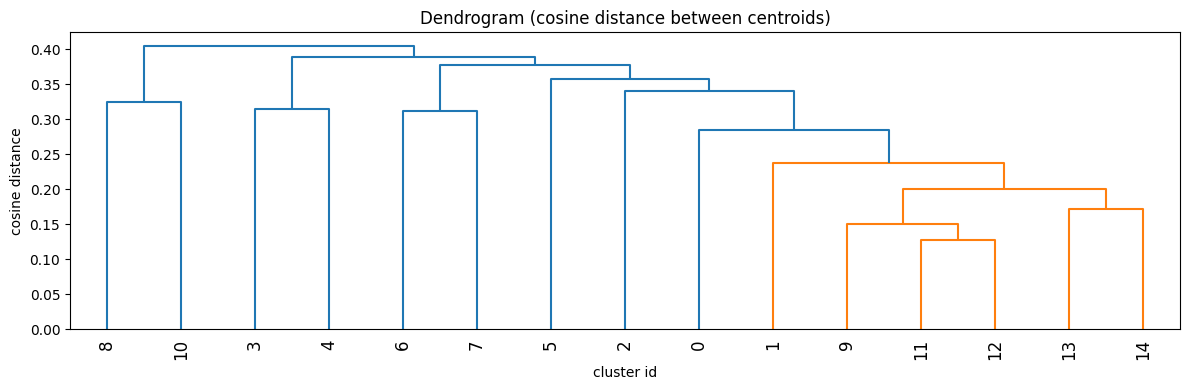

,cluster,nearest_cluster,nearest_cosine_distance
4,4,3,0.314734
3,3,12,0.303729
10,10,14,0.298772
8,8,14,0.292605
2,2,9,0.278544
7,7,14,0.277676
6,6,14,0.268929
5,5,12,0.229806
0,0,12,0.182457
13,13,14,0.171931


Nearest-distance median: 0.22980612516403198
Nearest-distance min: 0.1271948218345642
Nearest-distance max: 0.31473439931869507


,cluster,size,mean_prob,keywords,examples,segment_name
12,12,405,0.560620,"thankyou, thankyou much, fine, thanks, alright...",People do know Muslims don't actually burn whe...,thankyou | thankyou much | fine
2,2,365,0.861170,"lightsaber, buy, saber, one, game, its, lights...",(Pretends I didnt spend 2k a day buying Hearth...,lightsaber | buy | saber
14,14,175,0.531456,"people, broken, re, never, them, hate, someone...",Self hating Malays are the worst lmao. || But ...,people | broken | re
1,1,155,0.523505,"her, girl, cute, like, girlfriend, makeup, she...",@itisitiariff Siti I've been perfecting the dr...,her | girl | cute
4,4,117,0.748779,"hair, ugly, like, have, girls, people, skin, e...",@ihsnzlkfle it matches the hair. Yes || I dye ...,hair | ugly | like
7,7,87,0.628543,"him, his, guy, cute, man, look, hes, voice, cr...","RT @seoglyu: y'all got him feeling insecure,, ...",him | his | guy
10,10,83,0.766527,"sleep, final, exam, exams, crying, study, pape...",Sigh. Can I kill myself now || IM SO HAPPY I C...,sleep | final | exam
5,5,80,0.738449,"malay, word, words, hang, malaysia, malaysian,...",@puteih shes malaysian. Just not a Malay. Cina...,malay | word | words
9,9,76,0.508690,"2017, 2016, year, everyone, say, hope, best, b...",@vnndrws aw. Couldnt agree more. https://t.co/...,2017 | 2016 | year
11,11,74,0.472973,"love, re, yours, want, ll, try, yall, out ther...",@highzyl you should just prioritize me ok? || ...,love | re | yours


In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics.pairwise import cosine_distances
from sklearn.manifold import MDS

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "colab"

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform


def _normalize_cluster_report(cluster_report: pd.DataFrame) -> pd.DataFrame:
    """Забезпечує, що 'cluster' є колонкою (а не індексом), і що колонки існують."""
    rep = cluster_report.copy()
    if rep is None or len(rep) == 0:
        return pd.DataFrame(columns=["cluster", "mean_prob", "keywords", "examples"])

    if "cluster" not in rep.columns:
        rep = rep.reset_index()


    for col in ["mean_prob", "keywords", "examples"]:
        if col not in rep.columns:
            rep[col] = "" if col != "mean_prob" else np.nan

    rep["cluster"] = rep["cluster"].astype(int, errors="ignore")
    rep["keywords"] = rep["keywords"].fillna("")
    rep["examples"] = rep["examples"].fillna("")
    return rep[["cluster", "mean_prob", "keywords", "examples"]]


def make_segment_name(keywords: str, topk=3) -> str:
    parts = [w.strip() for w in str(keywords).split(",") if w.strip()]
    return " | ".join(parts[:topk]) if parts else ""


def build_centroid_summary(X_norm: np.ndarray, labels: np.ndarray, cluster_report: pd.DataFrame, noise_label=-1):
    """
    Повертає:
      summary: cluster, size, mean_prob, keywords, examples, segment_name
      dist: cosine distance matrix between centroids (KxK)
    """
    clusters = sorted([int(c) for c in np.unique(labels) if c != noise_label])
    sizes = np.array([int((labels == c).sum()) for c in clusters])

    centroids = np.vstack([X_norm[labels == c].mean(axis=0) for c in clusters])
    dist = cosine_distances(centroids, centroids)

    rep = _normalize_cluster_report(cluster_report)
    rep["segment_name"] = rep["keywords"].apply(lambda s: make_segment_name(s, topk=3))

    summary = pd.DataFrame({"cluster": clusters, "size": sizes}).merge(
        rep[["cluster", "mean_prob", "keywords", "examples", "segment_name"]],
        on="cluster",
        how="left"
    )

    summary["segment_name"] = summary["segment_name"].fillna(summary["cluster"].astype(str))
    summary["keywords"] = summary["keywords"].fillna("")
    summary["examples"] = summary["examples"].fillna("")
    return summary, dist


def plot_segment_map(summary: pd.DataFrame, dist: np.ndarray, title="Inter-segment distance map (centroids)"):

    mds = MDS(
        n_components=2,
        dissimilarity="precomputed",
        random_state=42,
        normalized_stress="auto"
    )
    coords = mds.fit_transform(dist)

    out = summary.copy()
    out["D1"] = coords[:, 0]
    out["D2"] = coords[:, 1]
    out["bubble"] = np.sqrt(out["size"].astype(float))

    fig = px.scatter(
        out,
        x="D1", y="D2",
        size="bubble",
        text="cluster",
        hover_data={
            "cluster": True,
            "size": True,
            "segment_name": True,
            "mean_prob": True,
            "keywords": True,
            "examples": True,
            "bubble": False
        },
        title=title
    )
    fig.update_traces(textposition="top center")
    fig.update_layout(height=650)
    fig.show()
    return out


def plot_cluster_dendrogram(dist: np.ndarray, clusters: list, title="Dendrogram (cosine distance between centroids)"):
    condensed = squareform(dist, checks=False)
    Z = linkage(condensed, method="average")

    plt.figure(figsize=(12, 4))
    dendrogram(Z, labels=[str(c) for c in clusters], leaf_rotation=90)
    plt.title(title)
    plt.xlabel("cluster id")
    plt.ylabel("cosine distance")
    plt.tight_layout()
    plt.show()


def separation_quick_stats(dist: np.ndarray, clusters: list):
    d = dist.copy()
    np.fill_diagonal(d, np.inf)
    nn = d.min(axis=1)
    nn_idx = d.argmin(axis=1)

    df_nn = pd.DataFrame({
        "cluster": clusters,
        "nearest_cluster": [clusters[i] for i in nn_idx],
        "nearest_cosine_distance": nn
    }).sort_values("nearest_cosine_distance", ascending=False)

    display(df_nn.head(15))
    print("Nearest-distance median:", float(np.median(nn)))
    print("Nearest-distance min:", float(np.min(nn)))
    print("Nearest-distance max:", float(np.max(nn)))





summary, dist = build_centroid_summary(X, labels_final, cluster_report, noise_label=-1)


seg_map = plot_segment_map(
    summary, dist,
    title="Inter-segment distance map (each segment is a separate bubble)"
)


plot_cluster_dendrogram(dist, clusters=summary["cluster"].tolist())


separation_quick_stats(dist, clusters=summary["cluster"].tolist())

display(summary.sort_values("size", ascending=False).head(15))


In [ ]:
import numpy as np
import plotly.express as px
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform


clusters = summary["cluster"].tolist()


condensed = squareform(dist, checks=False)
Z = linkage(condensed, method="average")
order = leaves_list(Z)

ordered_clusters = [clusters[i] for i in order]
dist_ord = dist[np.ix_(order, order)]

fig = px.imshow(
    dist_ord,
    x=[str(c) for c in ordered_clusters],
    y=[str(c) for c in ordered_clusters],
    aspect="auto",
    title="Cosine distance between segment centroids (ordered by dendrogram)"
)
fig.show()


In [ ]:
!pip -q install transformers sentencepiece accelerate

import re
import numpy as np
import pandas as pd
import torch

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM




MODEL_NAME = "google/flan-t5-base"
TITLE_LANG = "en"
K_EXAMPLES = 10
MAX_INPUT_CHARS = 1400
BATCH_SIZE = 8




tok = AutoTokenizer.from_pretrained(MODEL_NAME)
mdl = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to("cuda" if torch.cuda.is_available() else "cpu")
mdl.eval()




def clean_tweet(t: str) -> str:
    t = str(t)
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    t = re.sub(r"@\w+", " ", t)
    t = re.sub(r"\bRT\b", " ", t)
    t = re.sub(r"#\w+", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def pick_representative_texts(df: pd.DataFrame, cluster_id: int, k=10) -> list[str]:
    sub = df[df["cluster"] == cluster_id].copy()

    if "prob" in sub.columns:
        sub = sub.sort_values("prob", ascending=False)
    sub = sub.head(k)

    texts = [clean_tweet(x) for x in sub["post_text"].astype(str).tolist()]

    texts = [t for t in texts if len(t) >= 10]
    return texts[:k]




def build_prompt(cluster_id: int, keywords: str, examples: list[str], lang="en") -> str:
    if lang == "uk":
        instr = (
            "Ти маєш назвати комунікативний сегмент (тему кластера) за прикладами коротких твітів.\n"
            "Правила:\n"
            "1) Дай КОРОТКУ назву 2–5 слів, іменниковою фразою.\n"
            "2) НЕ копіюй жоден твіт дослівно.\n"
            "3) Не використовуй @, URL, числа/роки, лапки.\n"
            "4) Назва має відображати СУТНІСТЬ теми.\n"
            "Виведи ТІЛЬКИ назву.\n"
        )
    else:
        instr = (
            "You must label a communication segment (cluster topic) from short tweets.\n"
            "Rules:\n"
            "1) Output a SHORT title of 2–5 words (noun phrase).\n"
            "2) DO NOT copy any tweet text verbatim.\n"
            "3) Do not use @, URLs, numbers/years, quotes.\n"
            "4) Title must capture the underlying topic.\n"
            "Return ONLY the title.\n"
        )

    kw = (keywords or "").strip()
    ex_block = "\n".join([f"- {e[:180]}" for e in examples])

    prompt = f"{instr}\nKeywords: {kw}\nExamples:\n{ex_block}\nTitle:"

    return prompt[:MAX_INPUT_CHARS]

def is_bad_title(s: str) -> bool:
    s = (s or "").strip()
    if len(s) < 4:
        return True
    if "http" in s.lower() or "www" in s.lower():
        return True
    if "@" in s:
        return True

    if len(s.split()) > 7:
        return True

    if s.count(":") >= 1:
        return True
    return False

def normalize_title(s: str) -> str:
    s = (s or "").strip()
    s = re.sub(r'["“”]', "", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"[\.!\?]+$", "", s).strip()
    return s

@torch.no_grad()
def generate_titles(prompts: list[str]) -> list[str]:
    device = mdl.device
    enc = tok(prompts, return_tensors="pt", padding=True, truncation=True).to(device)
    out = mdl.generate(
        **enc,
        max_new_tokens=10,
        num_beams=5,
        do_sample=False,
        no_repeat_ngram_size=3,
        early_stopping=True
    )
    texts = tok.batch_decode(out, skip_special_tokens=True)
    return [normalize_title(t) for t in texts]

def repair_title(bad_title: str, lang="en") -> str:

    if lang == "uk":
        p = f"Перепиши у вигляді назви 2–5 слів (іменникова фраза), без деталей і без цитат: {bad_title}\nНазва:"
    else:
        p = f"Rewrite as a 2–5 word noun-phrase topic title, no details, no quotes: {bad_title}\nTitle:"
    return generate_titles([p])[0]




rep = None
if "cluster_report" in globals() and isinstance(cluster_report, pd.DataFrame) and len(cluster_report) > 0:
    rep = cluster_report.copy()
    if "cluster" not in rep.columns:
        rep = rep.reset_index()
else:
    rep = pd.DataFrame(columns=["cluster", "keywords"])




clusters = sorted([int(c) for c in user_df["cluster"].unique() if c != -1])

prompts = []
meta = []
for c in clusters:
    row = rep[rep["cluster"] == c] if len(rep) else None
    keywords = row["keywords"].iloc[0] if (row is not None and len(row) > 0 and "keywords" in row.columns) else ""
    examples = pick_representative_texts(user_df, c, k=K_EXAMPLES)
    prompts.append(build_prompt(c, keywords, examples, lang=TITLE_LANG))
    meta.append((c, keywords, examples))


titles = []
for i in range(0, len(prompts), BATCH_SIZE):
    titles.extend(generate_titles(prompts[i:i+BATCH_SIZE]))


final_titles = []
for t in titles:
    if is_bad_title(t):
        t2 = repair_title(t, lang=TITLE_LANG)
        final_titles.append(t2 if not is_bad_title(t2) else t[:40])
    else:
        final_titles.append(t)

names_df = pd.DataFrame({"cluster": clusters, "segment_title": final_titles})
display(names_df)


user_df = user_df.merge(names_df, on="cluster", how="left")
display(user_df[["post_created","post_text","cluster","segment_title","prob"]].head(20))


,cluster,segment_title
0,0,hmmm dia tak study
1,1,: . my 2 year old daughter singing
2,2,I really want to buy a lightsaber
3,3,Wait no. Azfar the Albino Alb
4,4,I hate wax
5,5,eh chabdkahs
6,6,My hambar game is strong today
7,7,: He might be the chef though please sto
8,8,God Eater Resurrection
9,9,I. JUST. FINISHED


KeyError: "['segment_title'] not in index"

Тренування нейромережі берттвіт

Dataset shape: (1879, 2)
Label distribution:
 burnout
1    1215
0     664
Name: count, dtype: int64

Fixed test: (188, 2) Rest: (1691, 2)


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0



================ RUN 1/4 | seed=42 ================


Map:   0%|          | 0/1503 [00:00<?, ? examples/s]

Map:   0%|          | 0/188 [00:00<?, ? examples/s]

...

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3062585707.py:111: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Roc Auc
1,0.695800,0.588366,0.675532,0.671432,0.687664,0.704794,0.777447
2,0.573000,0.533155,0.765957,0.743169,0.743169,0.743169,0.832650
3,0.356700,0.565482,0.781915,0.752306,0.764229,0.745032,0.860159
4,0.232700,0.585998,0.797872,0.782487,0.778257,0.788624,0.870219
5,0.158700,0.649411,0.781915,0.761503,0.760639,0.762419,0.873634



Per-epoch eval (last rows):


,run,seed,epoch,eval_loss,eval_accuracy,eval_f1_macro,eval_precision_macro,eval_recall_macro,eval_roc_auc
0,4,342,1.0,0.588366,0.675532,0.671432,0.687664,0.704794,0.777447
1,4,342,2.0,0.533155,0.765957,0.743169,0.743169,0.743169,0.832650
2,4,342,3.0,0.565482,0.781915,0.752306,0.764229,0.745032,0.860159
3,4,342,4.0,0.585998,0.797872,0.782487,0.778257,0.788624,0.870219
4,4,342,5.0,0.649411,0.781915,0.761503,0.760639,0.762419,0.873634



=== TEST Classification report (run 4) ===
                        precision    recall  f1-score   support

no_digital_fatigue (0)     0.6625    0.8030    0.7260        66
   digital_fatigue (1)     0.8796    0.7787    0.8261       122

              accuracy                         0.7872       188
             macro avg     0.7711    0.7909    0.7761       188
          weighted avg     0.8034    0.7872    0.7910       188

TEST ROC-AUC: 0.8751

All history shape: (19, 9)


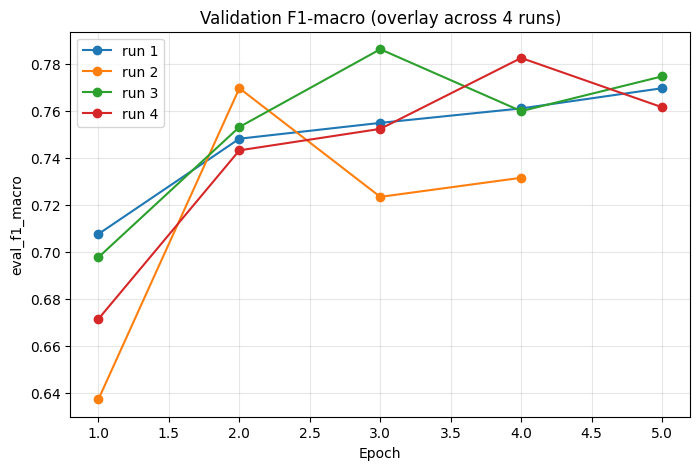

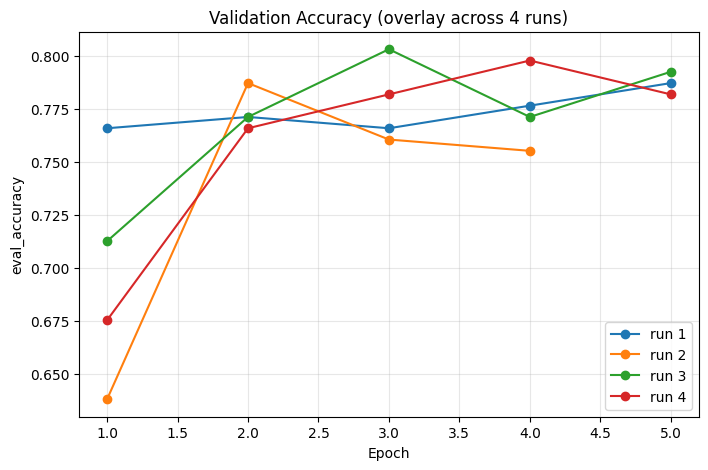

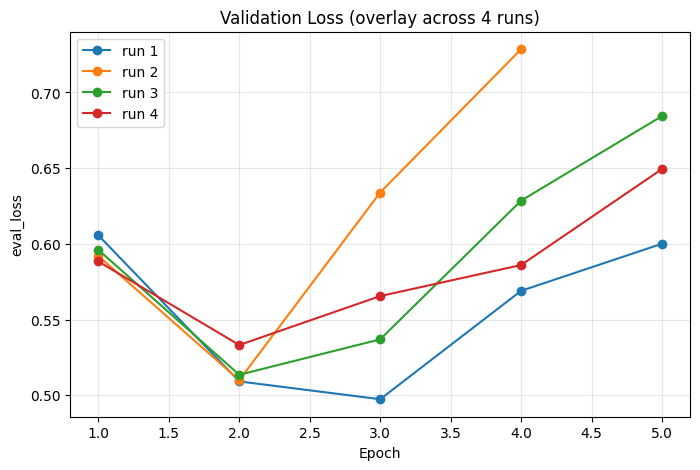

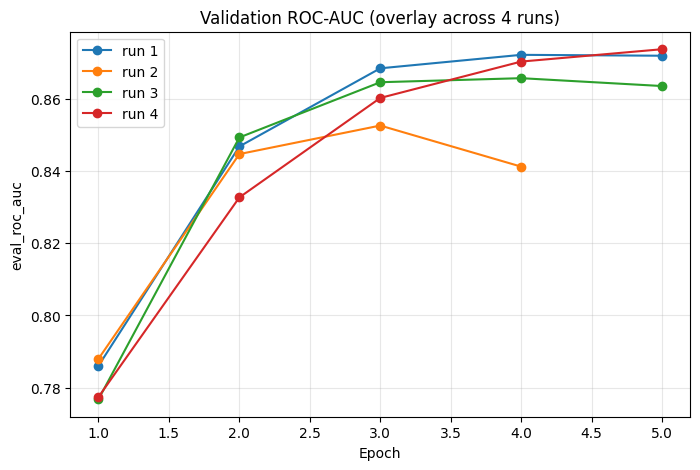


Test metrics per run:


,run,seed,test_accuracy,test_f1_macro,test_precision_macro,test_recall_macro,test_roc_auc
0,1,42,0.824468,0.809313,0.806540,0.812593,0.914928
1,2,142,0.771277,0.753108,0.749789,0.757700,0.837245
2,3,242,0.819149,0.798639,0.803635,0.794585,0.878788
3,4,342,0.787234,0.776057,0.771065,0.790859,0.875062



Test metrics: mean ± std
test_accuracy: 0.8005 ± 0.0255
test_f1_macro: 0.7843 ± 0.0250
test_precision_macro: 0.7828 ± 0.0272
test_recall_macro: 0.7889 ± 0.0229
test_roc_auc: 0.8765 ± 0.0318


In [ ]:
!pip -q install -U transformers datasets accelerate scikit-learn pandas matplotlib

from google.colab import files
import os, gc, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)


CSV_PATH = "/content/didjFetig.csv"
TEXT_COL = "Tweet Text"
LABEL_COL = "burnout"

MODEL_NAME = "vinai/bertweet-base"
MAX_LEN = 128

RUNS = 4
BASE_SEED = 42



RESPLIT_EACH_RUN = False

NUM_EPOCHS = 5
TRAIN_BS = 16
EVAL_BS = 32
LR = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06
EARLY_STOP_PATIENCE = 2



if not os.path.exists(CSV_PATH):
    uploaded = files.upload()




df = pd.read_csv(CSV_PATH)
df = df[[TEXT_COL, LABEL_COL]].copy()

df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df = df[df[TEXT_COL].notna() & (df[TEXT_COL].str.len() > 0)]

df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors="coerce")
df = df[df[LABEL_COL].notna()]
df[LABEL_COL] = df[LABEL_COL].astype(int)
df = df[df[LABEL_COL].isin([0, 1])].reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Label distribution:\n", df[LABEL_COL].value_counts())


TEST_SEED = BASE_SEED
rest_df, test_df = train_test_split(
    df, test_size=0.10, random_state=TEST_SEED, stratify=df[LABEL_COL]
)
print("\nFixed test:", test_df.shape, "Rest:", rest_df.shape)


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

def make_hf_dataset(frame: pd.DataFrame):
    ds = Dataset.from_pandas(
        frame.rename(columns={TEXT_COL: "text", LABEL_COL: "label"}),
        preserve_index=False
    )
    ds = ds.map(tokenize_batch, batched=True, remove_columns=["text"])
    return ds


import torch.nn as nn

class WeightedTrainer(Trainer):
    def __init__(self, class_weights_tensor=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights_tensor = class_weights_tensor

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights_tensor)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1m = f1_score(labels, preds, average="macro")
    precm = precision_score(labels, preds, average="macro", zero_division=0)
    recm = recall_score(labels, preds, average="macro", zero_division=0)


    try:
        probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
        auc = roc_auc_score(labels, probs)
    except Exception:
        auc = float("nan")

    return {
        "accuracy": acc,
        "f1_macro": f1m,
        "precision_macro": precm,
        "recall_macro": recm,
        "roc_auc": auc
    }


all_histories = []
test_summaries = []


if not RESPLIT_EACH_RUN:
    fixed_train_df, fixed_val_df = train_test_split(
        rest_df, test_size=0.111111, random_state=BASE_SEED, stratify=rest_df[LABEL_COL]
    )



for run in range(RUNS):
    run_seed = BASE_SEED + run * 100
    print(f"\n================ RUN {run+1}/{RUNS} | seed={run_seed} ================")


    set_seed(run_seed)
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    torch.cuda.manual_seed_all(run_seed)


    if RESPLIT_EACH_RUN:
        train_df, val_df = train_test_split(
            rest_df, test_size=0.111111, random_state=run_seed, stratify=rest_df[LABEL_COL]
        )
    else:
        train_df, val_df = fixed_train_df.copy(), fixed_val_df.copy()


    train_ds = make_hf_dataset(train_df)
    val_ds   = make_hf_dataset(val_df)
    test_ds  = make_hf_dataset(test_df)


    classes = np.array([0, 1])
    cw = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=train_df[LABEL_COL].values
    ).astype(np.float32)
    print("Class weights:", {int(c): float(w) for c, w in zip(classes, cw)})


    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)




    cw_tensor = torch.tensor(cw)


    out_dir = f"bertweet_burnout_run_{run+1}"
    args = TrainingArguments(
        output_dir=out_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=50,
        per_device_train_batch_size=TRAIN_BS,
        per_device_eval_batch_size=EVAL_BS,
        learning_rate=LR,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=run_seed
    )

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
        class_weights_tensor=None
    )


    trainer.class_weights_tensor = cw_tensor.to(trainer.model.device)


    trainer.train()



    eval_rows = []
    for item in trainer.state.log_history:
        if "eval_loss" in item and "epoch" in item:
            eval_rows.append({
                "run": run + 1,
                "seed": run_seed,
                "epoch": float(item.get("epoch")),
                "eval_loss": float(item.get("eval_loss")),
                "eval_accuracy": float(item.get("eval_accuracy", np.nan)),
                "eval_f1_macro": float(item.get("eval_f1_macro", np.nan)),
                "eval_precision_macro": float(item.get("eval_precision_macro", np.nan)),
                "eval_recall_macro": float(item.get("eval_recall_macro", np.nan)),
                "eval_roc_auc": float(item.get("eval_roc_auc", np.nan)),
            })
    hist_df = pd.DataFrame(eval_rows).sort_values(["epoch"])
    print("\nPer-epoch eval (last rows):")
    display(hist_df.tail())

    all_histories.append(hist_df)


    pred_out = trainer.predict(test_ds)
    test_logits = pred_out.predictions
    test_labels = pred_out.label_ids
    test_preds = np.argmax(test_logits, axis=-1)
    test_probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()[:, 1]

    test_acc = accuracy_score(test_labels, test_preds)
    test_f1m = f1_score(test_labels, test_preds, average="macro")
    test_precm = precision_score(test_labels, test_preds, average="macro", zero_division=0)
    test_recm = recall_score(test_labels, test_preds, average="macro", zero_division=0)
    test_auc = roc_auc_score(test_labels, test_probs)

    test_summaries.append({
        "run": run + 1,
        "seed": run_seed,
        "test_accuracy": test_acc,
        "test_f1_macro": test_f1m,
        "test_precision_macro": test_precm,
        "test_recall_macro": test_recm,
        "test_roc_auc": test_auc
    })

    print("\n=== TEST Classification report (run {}) ===".format(run+1))
    print(classification_report(
        test_labels,
        test_preds,
        target_names=["no_digital_fatigue (0)", "digital_fatigue (1)"],
        digits=4
    ))
    print(f"TEST ROC-AUC: {test_auc:.4f}")


    del trainer, model, train_ds, val_ds, test_ds
    torch.cuda.empty_cache()
    gc.collect()


hist_all = pd.concat(all_histories, ignore_index=True)
print("\nAll history shape:", hist_all.shape)


def plot_overlay(metric_col, title):
    plt.figure(figsize=(8, 5))
    for run_id in sorted(hist_all["run"].unique()):
        part = hist_all[hist_all["run"] == run_id].sort_values("epoch")
        plt.plot(part["epoch"], part[metric_col], marker="o", label=f"run {run_id}")
    plt.xlabel("Epoch")
    plt.ylabel(metric_col)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_overlay("eval_f1_macro", "Validation F1-macro (overlay across 4 runs)")
plot_overlay("eval_accuracy", "Validation Accuracy (overlay across 4 runs)")
plot_overlay("eval_loss", "Validation Loss (overlay across 4 runs)")
plot_overlay("eval_roc_auc", "Validation ROC-AUC (overlay across 4 runs)")


test_df_sum = pd.DataFrame(test_summaries)
print("\nTest metrics per run:")
display(test_df_sum)

print("\nTest metrics: mean ± std")
for col in ["test_accuracy", "test_f1_macro", "test_precision_macro", "test_recall_macro", "test_roc_auc"]:
    mean = test_df_sum[col].mean()
    std = test_df_sum[col].std(ddof=1)
    print(f"{col}: {mean:.4f} ± {std:.4f}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Dataset shape: (1879, 2)
Label distribution:
 burnout
1    1215
0     664
Name: count, dtype: int64

Splits (before balancing):
Rest: (1691, 2) Test: (188, 2)
Train: (1503, 2) Val: (188, 2)

Val label distribution:
 burnout
1    122
0     66
Name: count, dtype: int64

Test label distribution:
 burnout
1    122
0     66
Name: count, dtype: int64

================ RUN 1/4 | seed=42 ================
Train distribution before balancing:
 burnout
1    971
0    532
Name: count, dtype: int64
Train distribution after balancing:
 burnout
0    532
1    532
Name: count, dtype: int64


Map:   0%|          | 0/1064 [00:00<?, ? examples/s]

Map:   0%|          | 0/188 [00:00<?, ? examples/s]

Map:   0%|          | 0/188 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4093014399.py:268: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...


=== TEST Classification report (run 4) ===
                        precision    recall  f1-score   support

no_digital_fatigue (0)     0.5165    0.7121    0.5987        66
   digital_fatigue (1)     0.8041    0.6393    0.7123       122

              accuracy                         0.6649       188
             macro avg     0.6603    0.6757    0.6555       188
          weighted avg     0.7031    0.6649    0.6724       188

TEST ROC-AUC: 0.7602

Validation metrics per run:


,run,seed,val_accuracy,val_f1_macro,val_precision_macro,val_recall_macro,val_roc_auc
0,1,42,0.750000,0.741024,0.740241,0.762171,0.810606
1,2,142,0.765957,0.749637,0.745377,0.757079,0.813587
2,3,242,0.712766,0.703054,0.704091,0.723050,0.812593
3,4,342,0.691489,0.679746,0.680119,0.696225,0.792474



Validation metrics: mean ± std
val_accuracy: 0.7301 ± 0.0340
val_f1_macro: 0.7184 ± 0.0327
val_precision_macro: 0.7175 ± 0.0309
val_recall_macro: 0.7346 ± 0.0309
val_roc_auc: 0.8073 ± 0.0100

Test metrics per run:


,run,seed,test_accuracy,test_f1_macro,test_precision_macro,test_recall_macro,test_roc_auc
0,1,42,0.664894,0.640470,0.638535,0.644436,0.776826
1,2,142,0.744681,0.728422,0.724389,0.737208,0.804272
2,3,242,0.675532,0.659329,0.657955,0.670020,0.759314
3,4,342,0.664894,0.655527,0.660304,0.675733,0.760184



Test metrics: mean ± std
test_accuracy: 0.6875 ± 0.0384
test_f1_macro: 0.6709 ± 0.0392
test_precision_macro: 0.6703 ± 0.0374
test_recall_macro: 0.6818 ± 0.0393
test_roc_auc: 0.7751 ± 0.0210


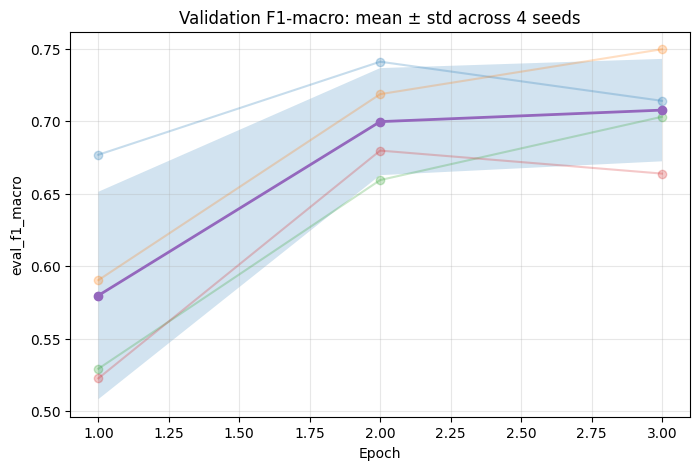

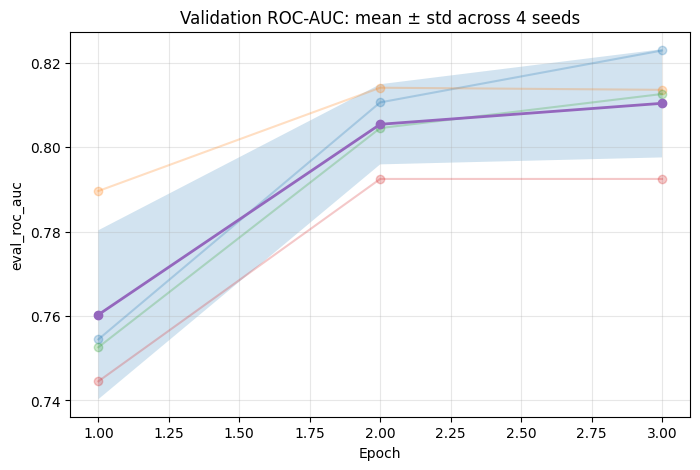

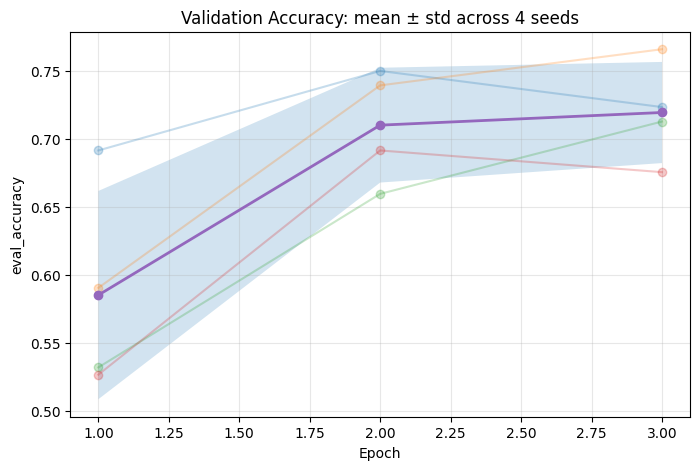

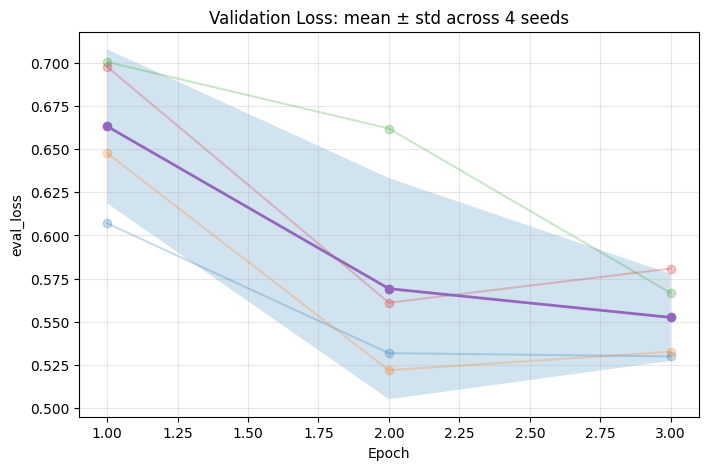

In [ ]:
!pip -q install -U transformers datasets accelerate scikit-learn matplotlib emoji==0.6.0

from google.colab import files
import os, gc, random, inspect
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed
)


CSV_PATH = "/content/didjFetig.csv"
TEXT_COL = "Tweet Text"
LABEL_COL = "burnout"

MODEL_NAME = "vinai/bertweet-base"
MAX_LEN = 128

RUNS = 4
BASE_SEED = 42


RESPLIT_EACH_RUN = False


NUM_EPOCHS = 3

TRAIN_BS = 16
EVAL_BS = 32
LR = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06




BALANCE_TRAIN = True
BALANCE_MODE = "downsample"


def ensure_file(path):
    if not os.path.exists(path):
        uploaded = files.upload()



def clean_df(df):
    df = df[[TEXT_COL, LABEL_COL]].copy()
    df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
    df = df[df[TEXT_COL].notna() & (df[TEXT_COL].str.len() > 0)]
    df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors="coerce")
    df = df[df[LABEL_COL].notna()]
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    df = df[df[LABEL_COL].isin([0, 1])].reset_index(drop=True)
    return df

def balance_binary_train(train_df, seed, mode="downsample"):
    vc = train_df[LABEL_COL].value_counts()
    if len(vc) < 2:
        return train_df

    n0 = int(vc.get(0, 0))
    n1 = int(vc.get(1, 0))
    if n0 == 0 or n1 == 0:
        return train_df

    df0 = train_df[train_df[LABEL_COL] == 0]
    df1 = train_df[train_df[LABEL_COL] == 1]

    if mode == "downsample":
        n = min(len(df0), len(df1))
        df0b = df0.sample(n=n, random_state=seed)
        df1b = df1.sample(n=n, random_state=seed)
        out = pd.concat([df0b, df1b], axis=0).sample(frac=1, random_state=seed).reset_index(drop=True)
        return out

    if mode == "upsample":
        n = max(len(df0), len(df1))
        df0b = df0.sample(n=n, replace=True, random_state=seed)
        df1b = df1.sample(n=n, replace=True, random_state=seed)
        out = pd.concat([df0b, df1b], axis=0).sample(frac=1, random_state=seed).reset_index(drop=True)
        return out

    return train_df

def compute_metrics_from_logits(logits, labels):
    preds = np.argmax(logits, axis=-1)
    probs1 = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]

    acc = accuracy_score(labels, preds)
    f1m = f1_score(labels, preds, average="macro")
    precm = precision_score(labels, preds, average="macro", zero_division=0)
    recm = recall_score(labels, preds, average="macro", zero_division=0)
    auc = roc_auc_score(labels, probs1) if len(np.unique(labels)) == 2 else float("nan")

    return acc, f1m, precm, recm, auc, preds, probs1

def hf_dataset_from_frame(frame):
    ds = Dataset.from_pandas(
        frame.rename(columns={TEXT_COL: "text", LABEL_COL: "label"}),
        preserve_index=False
    )
    ds = ds.map(lambda b: tokenizer(b["text"], truncation=True, max_length=MAX_LEN),
                batched=True,
                remove_columns=["text"])
    return ds


def build_training_args(**kwargs):
    sig = inspect.signature(TrainingArguments.__init__)
    allowed = set(sig.parameters.keys())
    if "eval_strategy" in allowed and "evaluation_strategy" in kwargs:
        kwargs["eval_strategy"] = kwargs.pop("evaluation_strategy")
    filtered = {k: v for k, v in kwargs.items() if k in allowed}
    return TrainingArguments(**filtered)

def trainer_compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1m = f1_score(labels, preds, average="macro")
    precm = precision_score(labels, preds, average="macro", zero_division=0)
    recm = recall_score(labels, preds, average="macro", zero_division=0)

    try:
        probs1 = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
        auc = roc_auc_score(labels, probs1) if len(np.unique(labels)) == 2 else float("nan")
    except Exception:
        auc = float("nan")

    return {"accuracy": acc, "f1_macro": f1m, "precision_macro": precm, "recall_macro": recm, "roc_auc": auc}

def plot_mean_std(hist_all, metric_col, title, show_individual=True):
    pv = hist_all.pivot_table(index="epoch", columns="run", values=metric_col, aggfunc="mean").sort_index()
    mean = pv.mean(axis=1)
    std = pv.std(axis=1, ddof=1)

    plt.figure(figsize=(8,5))
    if show_individual:
        for r in pv.columns:
            plt.plot(pv.index, pv[r], marker="o", alpha=0.25)

    plt.plot(mean.index, mean.values, marker="o", linewidth=2)
    plt.fill_between(mean.index, (mean-std).values, (mean+std).values, alpha=0.2)

    plt.xlabel("Epoch")
    plt.ylabel(metric_col)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()


ensure_file(CSV_PATH)

df = clean_df(pd.read_csv(CSV_PATH))
print("Dataset shape:", df.shape)
print("Label distribution:\n", df[LABEL_COL].value_counts())


TEST_SEED = BASE_SEED
rest_df, test_df = train_test_split(df, test_size=0.10, random_state=TEST_SEED, stratify=df[LABEL_COL])


if not RESPLIT_EACH_RUN:
    fixed_train_df, fixed_val_df = train_test_split(
        rest_df, test_size=0.111111, random_state=BASE_SEED, stratify=rest_df[LABEL_COL]
    )

print("\nSplits (before balancing):")
print("Rest:", rest_df.shape, "Test:", test_df.shape)
if not RESPLIT_EACH_RUN:
    print("Train:", fixed_train_df.shape, "Val:", fixed_val_df.shape)
print("\nVal label distribution:\n", (fixed_val_df if not RESPLIT_EACH_RUN else rest_df)[LABEL_COL].value_counts())
print("\nTest label distribution:\n", test_df[LABEL_COL].value_counts())


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

all_histories = []
val_summaries = []
test_summaries = []

for run in range(RUNS):
    run_seed = BASE_SEED + run * 100
    print(f"\n================ RUN {run+1}/{RUNS} | seed={run_seed} ================")

    set_seed(run_seed)
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    torch.cuda.manual_seed_all(run_seed)


    if RESPLIT_EACH_RUN:
        train_df, val_df = train_test_split(
            rest_df, test_size=0.111111, random_state=run_seed, stratify=rest_df[LABEL_COL]
        )
    else:
        train_df, val_df = fixed_train_df.copy(), fixed_val_df.copy()


    if BALANCE_TRAIN:
        before = train_df[LABEL_COL].value_counts()
        train_df = balance_binary_train(train_df, seed=run_seed, mode=BALANCE_MODE)
        after = train_df[LABEL_COL].value_counts()
        print("Train distribution before balancing:\n", before)
        print("Train distribution after balancing:\n", after)


    train_ds = hf_dataset_from_frame(train_df)
    val_ds   = hf_dataset_from_frame(val_df)
    test_ds  = hf_dataset_from_frame(test_df)


    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    args = build_training_args(
        output_dir=f"bertweet_burnout_run_{run+1}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=50,
        per_device_train_batch_size=TRAIN_BS,
        per_device_eval_batch_size=EVAL_BS,
        learning_rate=LR,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=run_seed
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=trainer_compute_metrics,
    )

    trainer.train()


    eval_rows = []
    for item in trainer.state.log_history:
        if "eval_loss" in item and "epoch" in item:
            eval_rows.append({
                "run": run + 1,
                "seed": run_seed,
                "epoch": float(item["epoch"]),
                "eval_loss": float(item.get("eval_loss")),
                "eval_accuracy": float(item.get("eval_accuracy", np.nan)),
                "eval_f1_macro": float(item.get("eval_f1_macro", np.nan)),
                "eval_precision_macro": float(item.get("eval_precision_macro", np.nan)),
                "eval_recall_macro": float(item.get("eval_recall_macro", np.nan)),
                "eval_roc_auc": float(item.get("eval_roc_auc", np.nan)),
            })
    hist_df = pd.DataFrame(eval_rows).sort_values("epoch")
    all_histories.append(hist_df)


    best_epoch = float(hist_df.loc[hist_df["eval_f1_macro"].idxmax(), "epoch"])
    best_f1 = float(hist_df["eval_f1_macro"].max())
    print(f"Best VAL F1-macro at epoch ~ {best_epoch:.1f} (F1={best_f1:.4f})")


    val_pred = trainer.predict(val_ds)
    val_logits = val_pred.predictions
    val_labels = val_pred.label_ids
    val_acc, val_f1m, val_precm, val_recm, val_auc, val_preds, _ = compute_metrics_from_logits(val_logits, val_labels)

    val_summaries.append({
        "run": run + 1, "seed": run_seed,
        "val_accuracy": val_acc,
        "val_f1_macro": val_f1m,
        "val_precision_macro": val_precm,
        "val_recall_macro": val_recm,
        "val_roc_auc": val_auc
    })

    print("\n=== VALIDATION Classification report (run {}) ===".format(run+1))
    print(classification_report(
        val_labels,
        val_preds,
        target_names=["no_digital_fatigue (0)", "digital_fatigue (1)"],
        digits=4
    ))
    print(f"VAL ROC-AUC: {val_auc:.4f}")


    test_pred = trainer.predict(test_ds)
    test_logits = test_pred.predictions
    test_labels = test_pred.label_ids
    test_acc, test_f1m, test_precm, test_recm, test_auc, test_preds, _ = compute_metrics_from_logits(test_logits, test_labels)

    test_summaries.append({
        "run": run + 1, "seed": run_seed,
        "test_accuracy": test_acc,
        "test_f1_macro": test_f1m,
        "test_precision_macro": test_precm,
        "test_recall_macro": test_recm,
        "test_roc_auc": test_auc
    })

    print("\n=== TEST Classification report (run {}) ===".format(run+1))
    print(classification_report(
        test_labels,
        test_preds,
        target_names=["no_digital_fatigue (0)", "digital_fatigue (1)"],
        digits=4
    ))
    print(f"TEST ROC-AUC: {test_auc:.4f}")


    del trainer, model, train_ds, val_ds, test_ds
    torch.cuda.empty_cache()
    gc.collect()


hist_all = pd.concat(all_histories, ignore_index=True)

val_df_sum = pd.DataFrame(val_summaries)
test_df_sum = pd.DataFrame(test_summaries)

print("\nValidation metrics per run:")
display(val_df_sum)

print("\nValidation metrics: mean ± std")
for col in ["val_accuracy","val_f1_macro","val_precision_macro","val_recall_macro","val_roc_auc"]:
    print(f"{col}: {val_df_sum[col].mean():.4f} ± {val_df_sum[col].std(ddof=1):.4f}")

print("\nTest metrics per run:")
display(test_df_sum)

print("\nTest metrics: mean ± std")
for col in ["test_accuracy","test_f1_macro","test_precision_macro","test_recall_macro","test_roc_auc"]:
    print(f"{col}: {test_df_sum[col].mean():.4f} ± {test_df_sum[col].std(ddof=1):.4f}")


plot_mean_std(hist_all, "eval_f1_macro", "Validation F1-macro: mean ± std across 4 seeds", show_individual=True)
plot_mean_std(hist_all, "eval_roc_auc", "Validation ROC-AUC: mean ± std across 4 seeds", show_individual=True)
plot_mean_std(hist_all, "eval_accuracy", "Validation Accuracy: mean ± std across 4 seeds", show_individual=True)
plot_mean_std(hist_all, "eval_loss", "Validation Loss: mean ± std across 4 seeds", show_individual=True)


Dataset shape: (1879, 2)
Label distribution:
 burnout
1    1215
0     664
Name: count, dtype: int64

Fixed splits:
Train: (1503, 2) Val: (188, 2) Test: (188, 2)
Val distribution:
 burnout
1    122
0     66
Name: count, dtype: int64
Test distribution:
 burnout
1    122
0     66
Name: count, dtype: int64

================ RUN 1/4 | seed=42 ================
Train before balancing:
 burnout
1    971
0    532
Name: count, dtype: int64
Train after balancing:
 burnout
1    971
0    971
Name: count, dtype: int64


Map:   0%|          | 0/1942 [00:00<?, ? examples/s]

Map:   0%|          | 0/188 [00:00<?, ? examples/s]

Map:   0%|          | 0/188 [00:00<?, ? examples/s]

Class weights: {0: 1.0, 1: 1.0}


...


=== TEST Classification report (run 4) ===
                        precision    recall  f1-score   support

no_digital_fatigue (0)     0.7692    0.7576    0.7634        66
   digital_fatigue (1)     0.8699    0.8770    0.8735       122

              accuracy                         0.8351       188
             macro avg     0.8196    0.8173    0.8184       188
          weighted avg     0.8346    0.8351    0.8348       188

TEST ROC-AUC: 0.8846

Validation metrics per run:


,run,seed,val_accuracy,val_f1_macro,val_precision_macro,val_recall_macro,val_roc_auc
0,1,42,0.792553,0.773137,0.772234,0.774093,0.862891
1,2,142,0.776596,0.738196,0.764928,0.727024,0.796883
2,3,242,0.797872,0.771377,0.782228,0.764282,0.869039
3,4,342,0.787234,0.772397,0.767662,0.780427,0.845628



Validation metrics: mean ± std
val_accuracy: 0.7886 ± 0.0091
val_f1_macro: 0.7638 ± 0.0171
val_precision_macro: 0.7718 ± 0.0076
val_recall_macro: 0.7615 ± 0.0239
val_roc_auc: 0.8436 ± 0.0327

Test metrics per run:


,run,seed,test_accuracy,test_f1_macro,test_precision_macro,test_recall_macro,test_roc_auc
0,1,42,0.744681,0.717824,0.719506,0.716344,0.839978
1,2,142,0.792553,0.753289,0.790780,0.739319,0.853515
2,3,242,0.787234,0.755208,0.773355,0.745653,0.885991
3,4,342,0.835106,0.818414,0.819575,0.817312,0.884625



Test metrics: mean ± std
test_accuracy: 0.7899 ± 0.0370
test_f1_macro: 0.7612 ± 0.0418
test_precision_macro: 0.7758 ± 0.0421
test_recall_macro: 0.7547 ± 0.0436
test_roc_auc: 0.8660 ± 0.0229


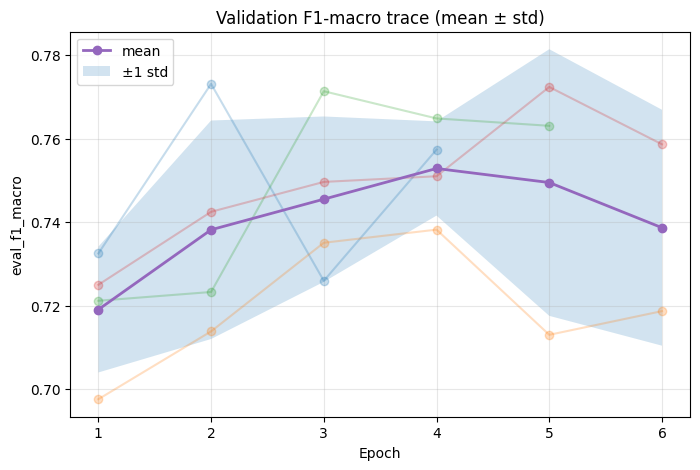

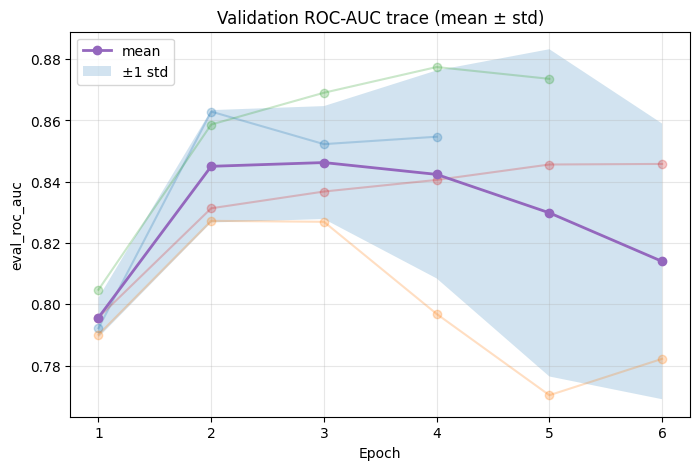

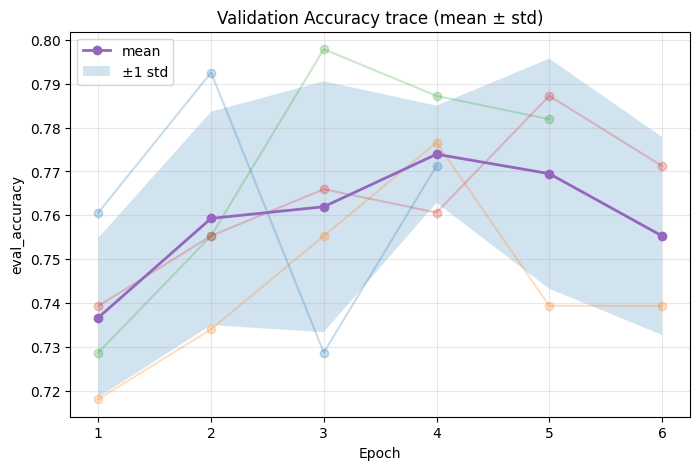

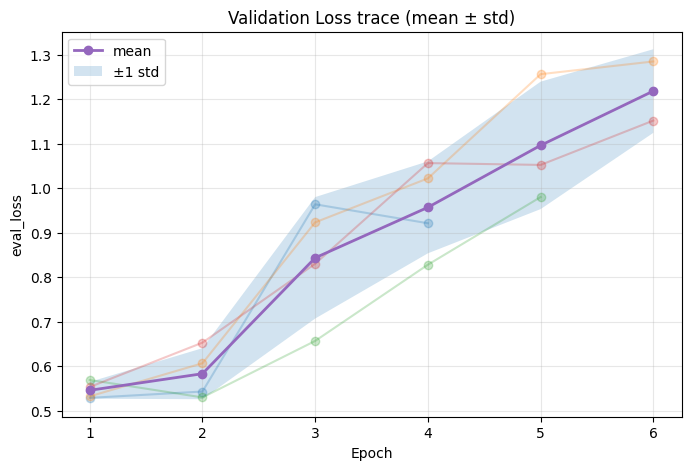

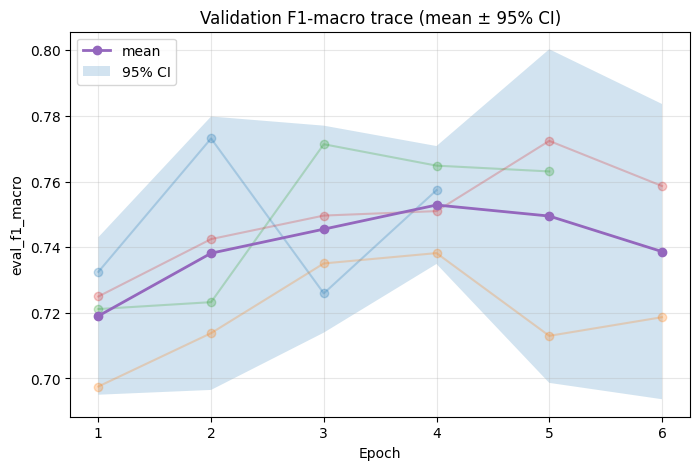

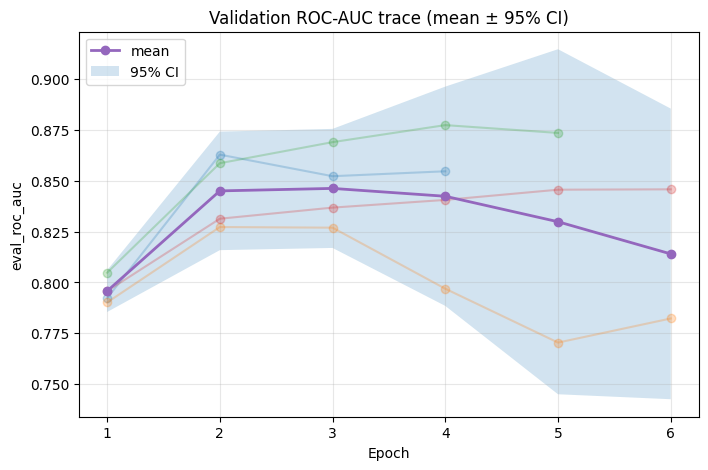

In [ ]:
!pip -q install -U transformers datasets accelerate scikit-learn matplotlib emoji==0.6.0

from google.colab import files
import os, gc, random, re, inspect
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)

from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, TrainingArguments, Trainer,
    EarlyStoppingCallback, set_seed
)


CSV_PATH = "/content/didjFetig.csv"
TEXT_COL = "Tweet Text"
LABEL_COL = "burnout"


MODEL_NAME = "vinai/bertweet-base"




MAX_LEN = 128
RUNS = 4
BASE_SEED = 42



MAX_EPOCHS = 6
EARLY_STOP_PATIENCE = 2

TRAIN_BS = 16
EVAL_BS = 32
LR = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06


BALANCE_TRAIN = True
BALANCE_MODE = "upsample"


NORMALIZE_TWEETS = True


if not os.path.exists(CSV_PATH):
    uploaded = files.upload()


df = pd.read_csv(CSV_PATH)[[TEXT_COL, LABEL_COL]].copy()
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df = df[df[TEXT_COL].notna() & (df[TEXT_COL].str.len() > 0)]
df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors="coerce")
df = df[df[LABEL_COL].notna()]
df[LABEL_COL] = df[LABEL_COL].astype(int)
df = df[df[LABEL_COL].isin([0, 1])].reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Label distribution:\n", df[LABEL_COL].value_counts())


TEST_SEED = BASE_SEED
rest_df, test_df = train_test_split(df, test_size=0.10, random_state=TEST_SEED, stratify=df[LABEL_COL])
train_df_fixed, val_df_fixed = train_test_split(
    rest_df, test_size=0.111111, random_state=BASE_SEED, stratify=rest_df[LABEL_COL]
)
print("\nFixed splits:")
print("Train:", train_df_fixed.shape, "Val:", val_df_fixed.shape, "Test:", test_df.shape)
print("Val distribution:\n", val_df_fixed[LABEL_COL].value_counts())
print("Test distribution:\n", test_df[LABEL_COL].value_counts())


url_re = re.compile(r"(https?://\S+|www\.\S+)")
user_re = re.compile(r"@\w+")

def normalize_tweet(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = text.strip()
    t = url_re.sub("HTTPURL", t)
    t = user_re.sub("@USER", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def make_hf_dataset(frame: pd.DataFrame):
    frame = frame.copy()
    if NORMALIZE_TWEETS:
        frame[TEXT_COL] = frame[TEXT_COL].apply(normalize_tweet)
    ds = Dataset.from_pandas(frame.rename(columns={TEXT_COL: "text", LABEL_COL: "label"}), preserve_index=False)

    def tok(batch):
        return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

    ds = ds.map(tok, batched=True, remove_columns=["text"])
    return ds


def balance_train_binary(train_df: pd.DataFrame, seed: int, mode: str = "upsample"):
    vc = train_df[LABEL_COL].value_counts()
    if len(vc) < 2:
        return train_df
    df0 = train_df[train_df[LABEL_COL] == 0]
    df1 = train_df[train_df[LABEL_COL] == 1]
    if len(df0) == 0 or len(df1) == 0:
        return train_df

    if mode == "upsample":
        n = max(len(df0), len(df1))
        df0b = df0.sample(n=n, replace=True, random_state=seed)
        df1b = df1.sample(n=n, replace=True, random_state=seed)
    else:
        n = min(len(df0), len(df1))
        df0b = df0.sample(n=n, replace=False, random_state=seed)
        df1b = df1.sample(n=n, replace=False, random_state=seed)

    out = pd.concat([df0b, df1b], axis=0).sample(frac=1, random_state=seed).reset_index(drop=True)
    return out


import torch.nn as nn

class WeightedTrainer(Trainer):
    def __init__(self, class_weights_tensor=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights_tensor = class_weights_tensor

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights_tensor)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def trainer_compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1m = f1_score(labels, preds, average="macro")
    precm = precision_score(labels, preds, average="macro", zero_division=0)
    recm = recall_score(labels, preds, average="macro", zero_division=0)

    try:
        probs1 = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
        auc = roc_auc_score(labels, probs1) if len(np.unique(labels)) == 2 else float("nan")
    except Exception:
        auc = float("nan")

    return {"accuracy": acc, "f1_macro": f1m, "precision_macro": precm, "recall_macro": recm, "roc_auc": auc}

def compute_from_logits(logits, labels):
    preds = np.argmax(logits, axis=-1)
    probs1 = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    acc = accuracy_score(labels, preds)
    f1m = f1_score(labels, preds, average="macro")
    precm = precision_score(labels, preds, average="macro", zero_division=0)
    recm = recall_score(labels, preds, average="macro", zero_division=0)
    auc = roc_auc_score(labels, probs1) if len(np.unique(labels)) == 2 else float("nan")
    return acc, f1m, precm, recm, auc, preds


def build_training_args(**kwargs):
    sig = inspect.signature(TrainingArguments.__init__)
    allowed = set(sig.parameters.keys())
    if "eval_strategy" in allowed and "evaluation_strategy" in kwargs:
        kwargs["eval_strategy"] = kwargs.pop("evaluation_strategy")
    filtered = {k: v for k, v in kwargs.items() if k in allowed}
    return TrainingArguments(**filtered)


def plot_trace(hist_all, metric_col, title, band="std"):
    """
    band="std"  -> mean ± std
    band="ci95" -> mean ± 95% CI (t-based, n=RUNS small)
    """
    pv = hist_all.pivot_table(index="epoch", columns="run", values=metric_col, aggfunc="mean").sort_index()
    mean = pv.mean(axis=1)
    std = pv.std(axis=1, ddof=1)

    n = pv.shape[1]
    if band == "ci95":

        tcrit = {2:12.706, 3:4.303, 4:3.182, 5:2.776}.get(n, 1.96)
        se = std / np.sqrt(n)
        lo = mean - tcrit * se
        hi = mean + tcrit * se
        band_label = "95% CI"
    else:
        lo = mean - std
        hi = mean + std
        band_label = "±1 std"

    plt.figure(figsize=(8,5))

    for r in pv.columns:
        plt.plot(pv.index, pv[r], marker="o", alpha=0.25)


    plt.plot(mean.index, mean.values, marker="o", linewidth=2, label="mean")
    plt.fill_between(mean.index, lo.values, hi.values, alpha=0.2, label=band_label)

    plt.xlabel("Epoch")
    plt.ylabel(metric_col)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


all_histories = []
val_summaries = []
test_summaries = []

for run in range(RUNS):
    run_seed = BASE_SEED + run * 100
    print(f"\n================ RUN {run+1}/{RUNS} | seed={run_seed} ================")

    set_seed(run_seed)
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    torch.cuda.manual_seed_all(run_seed)

    train_df = train_df_fixed.copy()
    val_df = val_df_fixed.copy()

    if BALANCE_TRAIN:
        before = train_df[LABEL_COL].value_counts()
        train_df = balance_train_binary(train_df, seed=run_seed, mode=BALANCE_MODE)
        after = train_df[LABEL_COL].value_counts()
        print("Train before balancing:\n", before)
        print("Train after balancing:\n", after)


    train_ds = make_hf_dataset(train_df)
    val_ds   = make_hf_dataset(val_df)
    test_ds  = make_hf_dataset(test_df)


    classes = np.array([0,1])
    cw = compute_class_weight("balanced", classes=classes, y=train_df[LABEL_COL].values).astype(np.float32)
    print("Class weights:", {int(c): float(w) for c, w in zip(classes, cw)})

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    args = build_training_args(
        output_dir=f"model_run_{run+1}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=50,
        per_device_train_batch_size=TRAIN_BS,
        per_device_eval_batch_size=EVAL_BS,
        learning_rate=LR,
        num_train_epochs=MAX_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=run_seed
    )

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=trainer_compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
        class_weights_tensor=None
    )

    trainer.class_weights_tensor = torch.tensor(cw).to(trainer.model.device)

    trainer.train()


    eval_rows = []
    for item in trainer.state.log_history:
        if "eval_loss" in item and "epoch" in item:
            eval_rows.append({
                "run": run + 1,
                "seed": run_seed,
                "epoch": float(item["epoch"]),
                "eval_loss": float(item.get("eval_loss")),
                "eval_accuracy": float(item.get("eval_accuracy", np.nan)),
                "eval_f1_macro": float(item.get("eval_f1_macro", np.nan)),
                "eval_precision_macro": float(item.get("eval_precision_macro", np.nan)),
                "eval_recall_macro": float(item.get("eval_recall_macro", np.nan)),
                "eval_roc_auc": float(item.get("eval_roc_auc", np.nan)),
            })
    hist_df = pd.DataFrame(eval_rows).sort_values("epoch")
    all_histories.append(hist_df)


    val_pred = trainer.predict(val_ds)
    v_acc, v_f1, v_prec, v_rec, v_auc, v_preds = compute_from_logits(val_pred.predictions, val_pred.label_ids)

    val_summaries.append({
        "run": run+1, "seed": run_seed,
        "val_accuracy": v_acc,
        "val_f1_macro": v_f1,
        "val_precision_macro": v_prec,
        "val_recall_macro": v_rec,
        "val_roc_auc": v_auc
    })

    print("\n=== VALIDATION Classification report (run {}) ===".format(run+1))
    print(classification_report(
        val_pred.label_ids, v_preds,
        target_names=["no_digital_fatigue (0)", "digital_fatigue (1)"],
        digits=4
    ))
    print(f"VAL ROC-AUC: {v_auc:.4f}")


    test_pred = trainer.predict(test_ds)
    t_acc, t_f1, t_prec, t_rec, t_auc, t_preds = compute_from_logits(test_pred.predictions, test_pred.label_ids)

    test_summaries.append({
        "run": run+1, "seed": run_seed,
        "test_accuracy": t_acc,
        "test_f1_macro": t_f1,
        "test_precision_macro": t_prec,
        "test_recall_macro": t_rec,
        "test_roc_auc": t_auc
    })

    print("\n=== TEST Classification report (run {}) ===".format(run+1))
    print(classification_report(
        test_pred.label_ids, t_preds,
        target_names=["no_digital_fatigue (0)", "digital_fatigue (1)"],
        digits=4
    ))
    print(f"TEST ROC-AUC: {t_auc:.4f}")


    del trainer, model, train_ds, val_ds, test_ds
    torch.cuda.empty_cache()
    gc.collect()


hist_all = pd.concat(all_histories, ignore_index=True)

val_df_sum = pd.DataFrame(val_summaries)
test_df_sum = pd.DataFrame(test_summaries)

print("\nValidation metrics per run:")
display(val_df_sum)

print("\nValidation metrics: mean ± std")
for col in ["val_accuracy","val_f1_macro","val_precision_macro","val_recall_macro","val_roc_auc"]:
    print(f"{col}: {val_df_sum[col].mean():.4f} ± {val_df_sum[col].std(ddof=1):.4f}")

print("\nTest metrics per run:")
display(test_df_sum)

print("\nTest metrics: mean ± std")
for col in ["test_accuracy","test_f1_macro","test_precision_macro","test_recall_macro","test_roc_auc"]:
    print(f"{col}: {test_df_sum[col].mean():.4f} ± {test_df_sum[col].std(ddof=1):.4f}")


plot_trace(hist_all, "eval_f1_macro", "Validation F1-macro trace (mean ± std)", band="std")
plot_trace(hist_all, "eval_roc_auc", "Validation ROC-AUC trace (mean ± std)", band="std")
plot_trace(hist_all, "eval_accuracy", "Validation Accuracy trace (mean ± std)", band="std")
plot_trace(hist_all, "eval_loss", "Validation Loss trace (mean ± std)", band="std")

plot_trace(hist_all, "eval_f1_macro", "Validation F1-macro trace (mean ± 95% CI)", band="ci95")
plot_trace(hist_all, "eval_roc_auc", "Validation ROC-AUC trace (mean ± 95% CI)", band="ci95")
